In [2]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma, erf
import scipy.stats as stats
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
sys.path.insert(0, 'ExistingLimits/')
import MichaelLimits as ML

import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess
import h5py
import time
import pickle
import glob

%matplotlib inline


In [2]:
mass_kg = 16.3e-3
t_days = 300.

SE = darklim.sensitivity.SensEst(mass_kg, t_days, eff=1., gain=1., tm='GaAs', seed=12345)
SE.reset_sim()
SE.add_lee_bkgd_from_file('required_performance_NR_like/background_spectrum_3fold.txt', scale_by=1e-10)

In [3]:
threshold_keV = 4.5e-3

gaas_params = {'N_PDs': 2,
                'E_th_PD': 1e-3,
                'E_res_PD': 0.163e-3,
                'E_th_GaAs': 4.5e-3,
                'E_res_GaAs': 0.9e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.3}


Confirming we are in the right directory
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning, GaAs_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of v

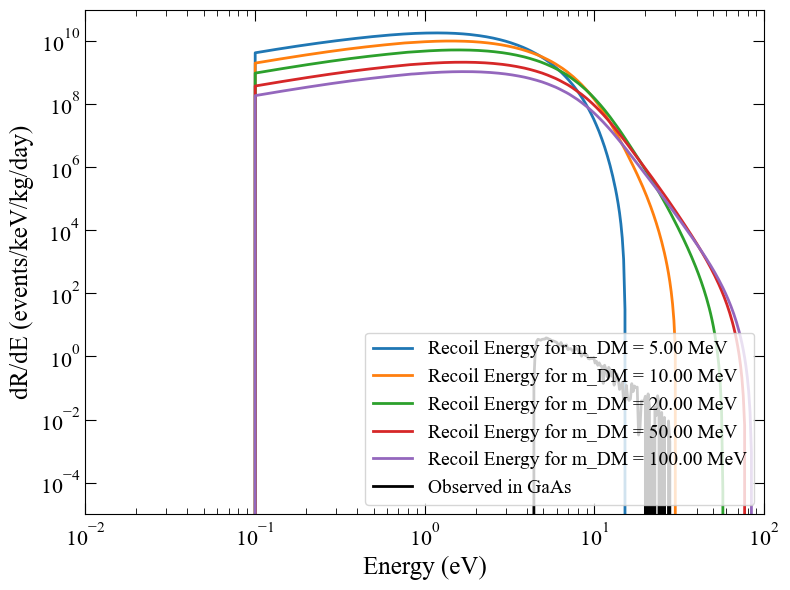

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))


for mX_eV in [5e6, 10e6, 20e6, 50e6, 100e6]:  # 1 MeV, 5 MeV, 10 MeV

    E_keV_arr = np.geomspace(1e-6, 100, 1000)
    
    gaas = darkelf.darkelf(target='GaAs', filename="GaAs_mermin.dat")
    gaas.update_params(mX=mX_eV, mediator='massless')

    elf_fun = lambda keV : gaas.dRdomega_electron(keV * 1000, sigmae=1e-31) * (1000 / 365.25) 
    dRdE_arr = np.array([elf_fun(E) for E in E_keV_arr])

    ax.plot(E_keV_arr * 1e3, dRdE_arr, label=f'Recoil Energy for m_DM = {mX_eV/1e6:.2f} MeV')
    
drde_function = SE.run_sim(threshold_keV, e_high=100., e_low=threshold_keV, m_dms=[100e-3], nexp=1, npts=1_000_000,
            plot_bkgd=False, res=None, verbose=False, sigma0=1e-37,
            elf_model='electron', elf_params={'mediator': 'massless'}, elf_target='GaAs',
            gaas_params=gaas_params, return_only_drde=True)[0]

dRdE_obs = np.array([drde_function(E) for E in E_keV_arr])
ax.plot(E_keV_arr * 1e3, dRdE_obs, label='Observed in GaAs', color='black')

# E_bkgd_arr, dRdE_bkgd_arr = np.loadtxt('required_performance_NR_like/background_spectrum_3fold.txt', unpack=True)
# ax.plot(E_bkgd_arr, dRdE_bkgd_arr / mass_kg, label='Background dR/dE', color='black')
ax.set_xscale('log')
ax.set_xlim([1e-2, 1e2])
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower right', fontsize=14)
fig.tight_layout()
fig.show()

Confirming we are in the right directory
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning, GaAs_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of v

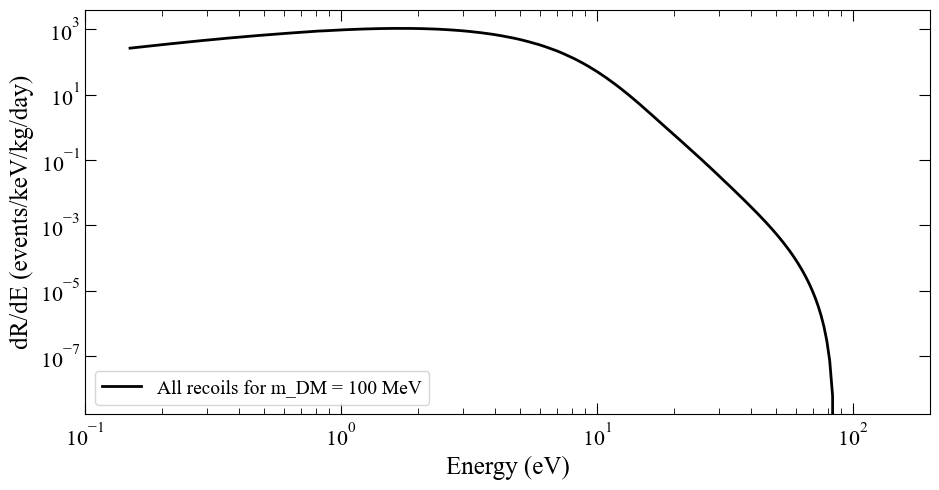

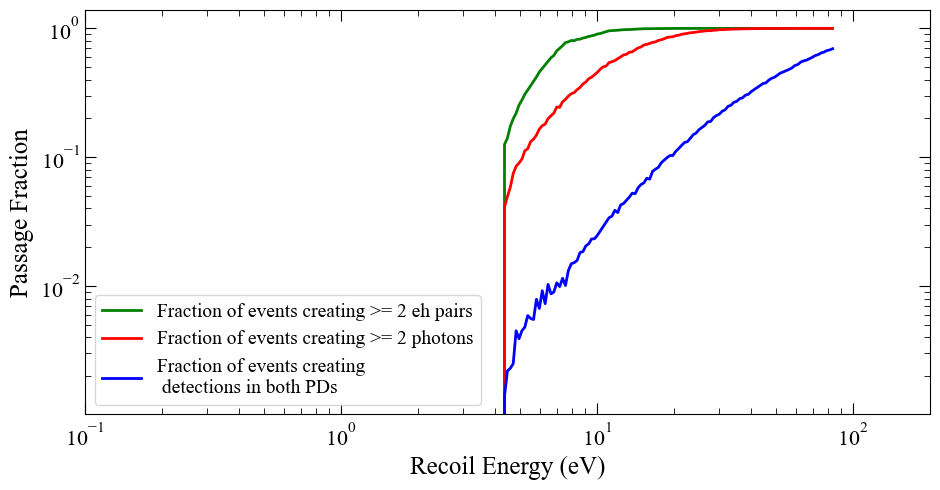

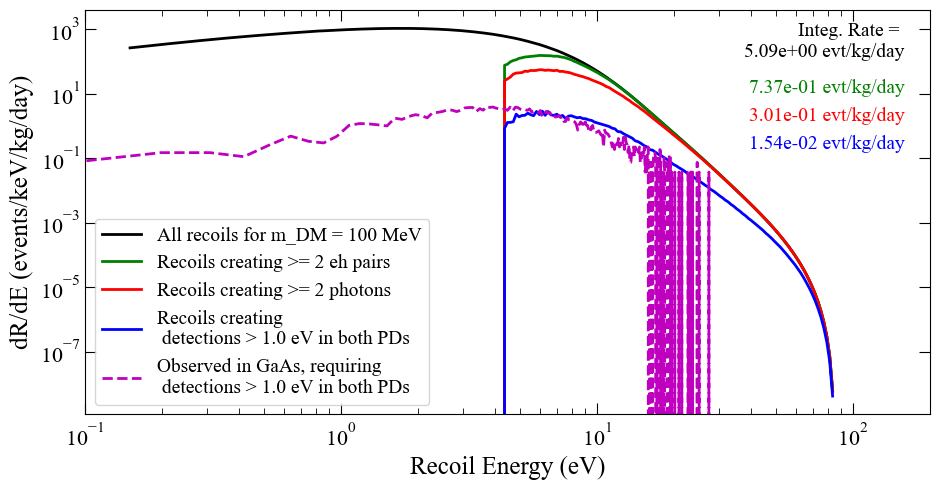

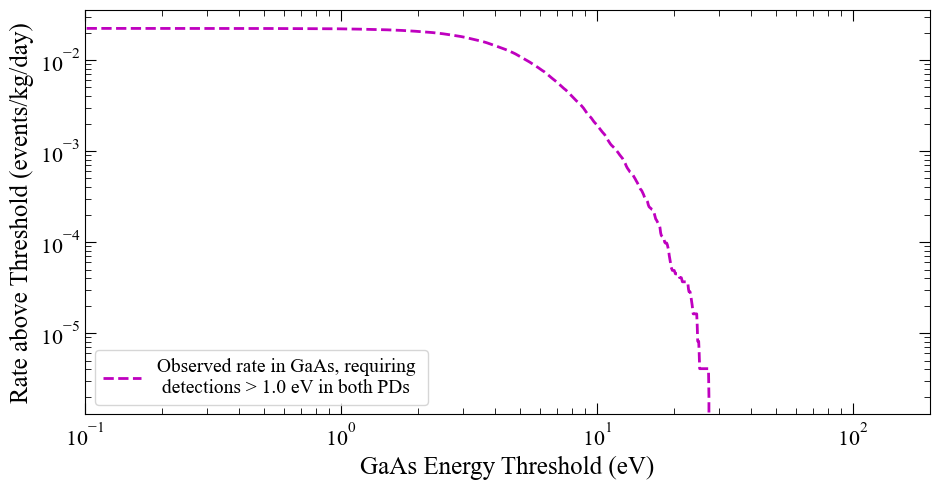

In [4]:
gaas_params = {'N_PDs': 2,
                'E_th_PD': 1e-3,
                'E_res_PD': 0.163e-3,
                'E_th_GaAs': 0.,
                'E_res_GaAs': 0.9e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.3}

mX_eV = 100e6
mX_GeV = mX_eV / 1e9
sigmae = 1e-37

E_keV_arr = np.geomspace(1.5e-4, 0.1, 250)

##################

fig, ax = plt.subplots(figsize=(9.5, 5))

gaas = darkelf.darkelf(target='GaAs', filename="GaAs_mermin.dat")
gaas.update_params(mX=mX_eV, mediator='massless')

elf_fun = lambda keV : gaas.dRdomega_electron(keV * 1000, sigmae=sigmae) * (1000 / 365.25) 
dRdE_arr = np.array([elf_fun(E) for E in E_keV_arr])

ax.plot(E_keV_arr * 1e3, dRdE_arr, 'k-', label=f'All recoils for m_DM = {mX_eV/1e6:.0f} MeV')
    
ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)
fig.tight_layout()
fig.show()

E_keV_ROI = E_keV_arr[dRdE_arr > 0]

##################

eff_2eh = np.zeros_like(E_keV_ROI)
eff_2photon = np.zeros_like(E_keV_ROI)
eff_2detected = np.zeros_like(E_keV_ROI)

for i, E_recoil in enumerate(E_keV_ROI):
    N_eh, N_photons, N_photons_PD_A, N_photons_PD_B, N_photons_sink, E_GaAs_keV, E_GaAs_obs_keV, E_PD_A_keV, E_PD_B_keV, detected, fraction_in_GaAs = \
        darklim.detector.monoenergetic_sim_GaAs(E_recoil, recoil = 'ER',
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = gaas_params['E_th_GaAs'], E_res_GaAs = gaas_params['E_res_GaAs'],
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(3567), n_sim = 10_000, verbose=False, verbose_return=True)

    eff_2eh[i] = sum(N_eh >= 2) / len(N_eh)
    eff_2photon[i] = sum(N_photons >= 2) / len(N_photons)
    eff_2detected[i] = sum((E_PD_A_keV > gaas_params['E_th_PD']) * (E_PD_B_keV > gaas_params['E_th_PD'])) / len(detected)

if i % 30 == 0:
        print(f'Completed {i} of {len(E_keV_ROI)} recoil energies')

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

ax.plot(E_keV_ROI * 1e3, eff_2eh, 'g-', lw=2, label=f'Fraction of events creating >= 2 eh pairs')
ax.plot(E_keV_ROI * 1e3, eff_2photon, 'r-', lw=2, label=f'Fraction of events creating >= 2 photons')
ax.plot(E_keV_ROI * 1e3, eff_2detected, 'b-', lw=2, label=f'Fraction of events creating \n detections in both PDs')

ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Passage Fraction')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

cut = dRdE_arr > 0

ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut], 'k-', label=f'All recoils for m_DM = {mX_eV/1e6:.0f} MeV')
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_2eh, 'g-', lw=2, label=f'Recoils creating >= 2 eh pairs')
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_2photon, 'r-', lw=2, label=f'Recoils creating >= 2 photons')
E_th_PD = gaas_params['E_th_PD']
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_2detected, 'b-', lw=2, label=f'Recoils creating \n detections > {E_th_PD*1e3:.1f} eV in both PDs')

R_all = np.trapz(dRdE_arr[cut], E_keV_ROI)
ax.text(0.97, 0.97, f'Integ. Rate = \n{R_all:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='k')
R_2eh = np.trapz(dRdE_arr[cut] * eff_2eh, E_keV_ROI)
ax.text(0.97, 0.83, f'{R_2eh:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='g')
R_2photon = np.trapz(dRdE_arr[cut] * eff_2photon, E_keV_ROI)
ax.text(0.97, 0.76, f'{R_2photon:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='r')
R_detected = np.trapz(dRdE_arr[cut] * eff_2detected, E_keV_ROI)
ax.text(0.97, 0.69, f'{R_detected:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='b')

E_GaAs_arr, dRdE_GaAs_arr = \
    darklim.detector.DM_spectrum_GaAs(mX_eV, sigmae, mediator='massless', e_high=1.,
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = 0., E_res_GaAs = gaas_params['E_res_GaAs'],
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(1389), n_sim = 1_000_000, verbose=False, plot=False)
ax.plot(E_GaAs_arr * 1e3, dRdE_GaAs_arr, 'm--', lw=2, label=f'Observed in GaAs, requiring \n detections > {E_th_PD*1e3:.1f} eV in both PDs')

ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

R_above_threshold_arr = np.zeros_like(E_GaAs_arr)
for i, E_GaAs in enumerate(E_GaAs_arr):
    R_above_threshold_arr[i] = np.trapz(dRdE_GaAs_arr[(E_GaAs_arr >= E_GaAs)], E_GaAs_arr[(E_GaAs_arr >= E_GaAs)])

ax.plot(E_GaAs_arr * 1e3, R_above_threshold_arr, 'm--', lw=2, label=f'Observed rate in GaAs, requiring \n detections > {E_th_PD*1e3:.1f} eV in both PDs')

ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('GaAs Energy Threshold (eV)')
ax.set_ylabel('Rate above Threshold (events/kg/day)')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()



Confirming we are in the right directory
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning, GaAs_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of v

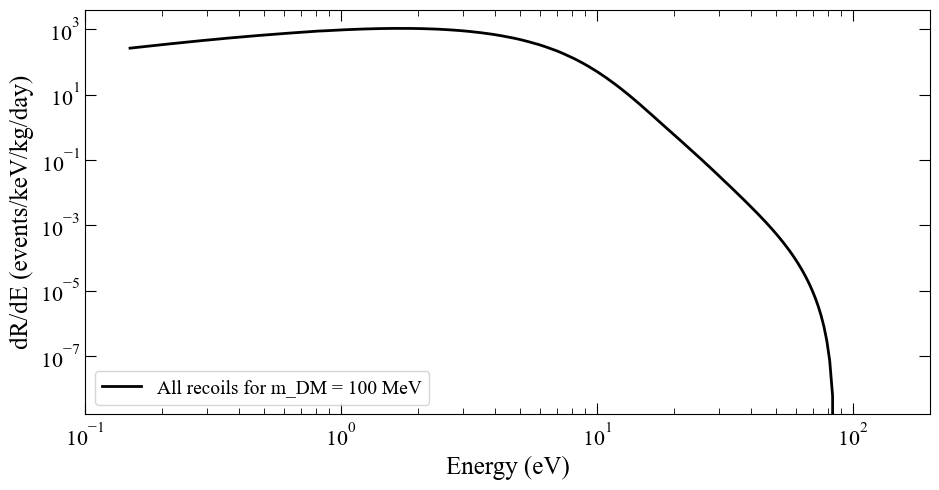

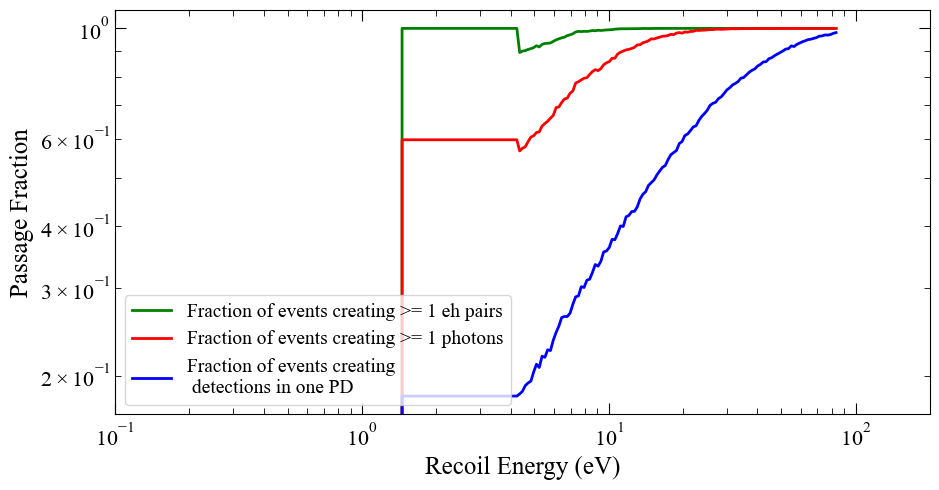

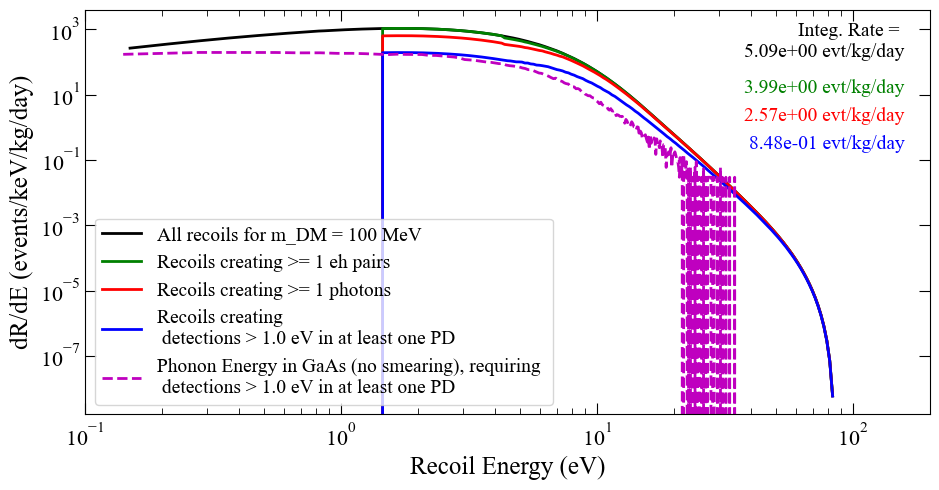

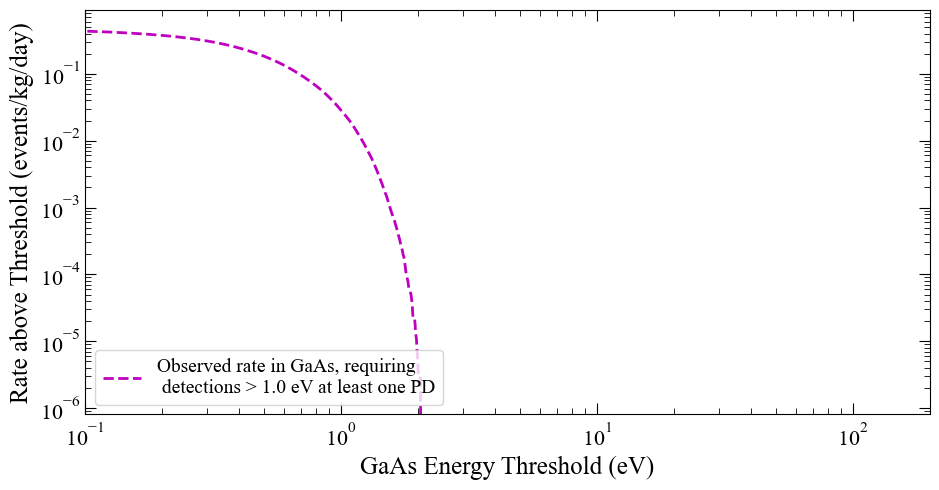

In [ ]:
gaas_params = {'N_PDs': 1,
                'E_th_PD': 1e-3,
                'E_res_PD': 0.127e-3,
                'E_th_GaAs': 0.,
                'E_res_GaAs': 0.223e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.3}

mX_eV = 100e6
mX_GeV = mX_eV / 1e9
sigmae = 1e-37

E_keV_arr = np.geomspace(1.5e-4, 0.1, 250)

##################

fig, ax = plt.subplots(figsize=(9.5, 5))

gaas = darkelf.darkelf(target='GaAs', filename="GaAs_mermin.dat")
gaas.update_params(mX=mX_eV, mediator='massless')

elf_fun = lambda keV : gaas.dRdomega_electron(keV * 1000, sigmae=sigmae) * (1000 / 365.25) 
dRdE_arr = np.array([elf_fun(E) for E in E_keV_arr])

ax.plot(E_keV_arr * 1e3, dRdE_arr, 'k-', label=f'All recoils for m_DM = {mX_eV/1e6:.0f} MeV')
    
ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)
fig.tight_layout()
fig.show()

E_keV_ROI = E_keV_arr[dRdE_arr > 0]

##################

eff_1eh = np.zeros_like(E_keV_ROI)
eff_1photon = np.zeros_like(E_keV_ROI)
eff_1detected = np.zeros_like(E_keV_ROI)

for i, E_recoil in enumerate(E_keV_ROI):
    N_eh, N_photons, N_photons_PD_A, N_photons_PD_B, N_photons_sink, E_GaAs_keV, E_GaAs_obs_keV, E_PD_A_keV, E_PD_B_keV, detected, fraction_in_GaAs = \
        darklim.detector.monoenergetic_sim_GaAs(E_recoil, recoil = 'ER',
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = gaas_params['E_th_GaAs'], E_res_GaAs = gaas_params['E_res_GaAs'],
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(34567), n_sim = 10_000, verbose=False, verbose_return=True)

    eff_1eh[i] = sum(N_eh >= 1) / len(N_eh)
    eff_1photon[i] = sum(N_photons >= 1) / len(N_photons)
    eff_1detected[i] = sum((E_PD_A_keV > gaas_params['E_th_PD']) + (E_PD_B_keV > gaas_params['E_th_PD'])) / len(detected)

if i % 30 == 0:
        print(f'Completed {i} of {len(E_keV_ROI)} recoil energies')

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

ax.plot(E_keV_ROI * 1e3, eff_1eh, 'g-', lw=2, label=f'Fraction of events creating >= 1 eh pairs')
ax.plot(E_keV_ROI * 1e3, eff_1photon, 'r-', lw=2, label=f'Fraction of events creating >= 1 photons')
ax.plot(E_keV_ROI * 1e3, eff_1detected, 'b-', lw=2, label=f'Fraction of events creating \n detections in one PD')

ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Passage Fraction')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

cut = dRdE_arr > 0

ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut], 'k-', label=f'All recoils for m_DM = {mX_eV/1e6:.0f} MeV')
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_1eh, 'g-', lw=2, label=f'Recoils creating >= 1 eh pairs')
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_1photon, 'r-', lw=2, label=f'Recoils creating >= 1 photons')
E_th_PD = gaas_params['E_th_PD']
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_1detected, 'b-', lw=2, label=f'Recoils creating \n detections > {E_th_PD*1e3:.1f} eV in at least one PD')

R_all = np.trapz(dRdE_arr[cut], E_keV_ROI)
ax.text(0.97, 0.97, f'Integ. Rate = \n{R_all:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='k')
R_2eh = np.trapz(dRdE_arr[cut] * eff_1eh, E_keV_ROI)
ax.text(0.97, 0.83, f'{R_2eh:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='g')
R_2photon = np.trapz(dRdE_arr[cut] * eff_1photon, E_keV_ROI)
ax.text(0.97, 0.76, f'{R_2photon:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='r')
R_detected = np.trapz(dRdE_arr[cut] * eff_1detected, E_keV_ROI)
ax.text(0.97, 0.69, f'{R_detected:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='b')

E_GaAs_arr_no_smearing, dRdE_GaAs_arr_no_smearing = \
    darklim.detector.DM_spectrum_GaAs(mX_eV, sigmae, mediator='massless', e_high=1.,
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = 0., E_res_GaAs = 0.,
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(13819), n_sim = 1_000_000, verbose=False, plot=False)

E_GaAs_arr_with_smearing, dRdE_GaAs_arr_with_smearing = \
    darklim.detector.DM_spectrum_GaAs(mX_eV, sigmae, mediator='massless', e_high=1.,
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = 0., E_res_GaAs = gaas_params['E_res_GaAs'],
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(13819), n_sim = 1_000_000, verbose=False, plot=False)

ax.plot(E_GaAs_arr_no_smearing * 1e3, dRdE_GaAs_arr_no_smearing, 'm--', lw=2, label=f'Phonon Energy in GaAs (no smearing), requiring \n detections > {E_th_PD*1e3:.1f} eV in at least one PD')

ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

R_above_threshold_arr = np.zeros_like(E_GaAs_arr)
for i, E_GaAs in enumerate(E_GaAs_arr):
    R_above_threshold_arr[i] = np.trapz(dRdE_GaAs_arr[(E_GaAs_arr >= E_GaAs)], E_GaAs_arr[(E_GaAs_arr >= E_GaAs)])

ax.plot(E_GaAs_arr * 1e3, R_above_threshold_arr, 'm--', lw=2, label=f'Observed rate in GaAs, requiring \n detections > {E_th_PD*1e3:.1f} eV at least one PD')

ax.set_xscale('log')
ax.set_xlim([1e-1, 2e2])
ax.set_yscale('log')
ax.set_xlabel('GaAs Energy Threshold (eV)')
ax.set_ylabel('Rate above Threshold (events/kg/day)')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()



Confirming we are in the right directory
 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning, GaAs_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of v

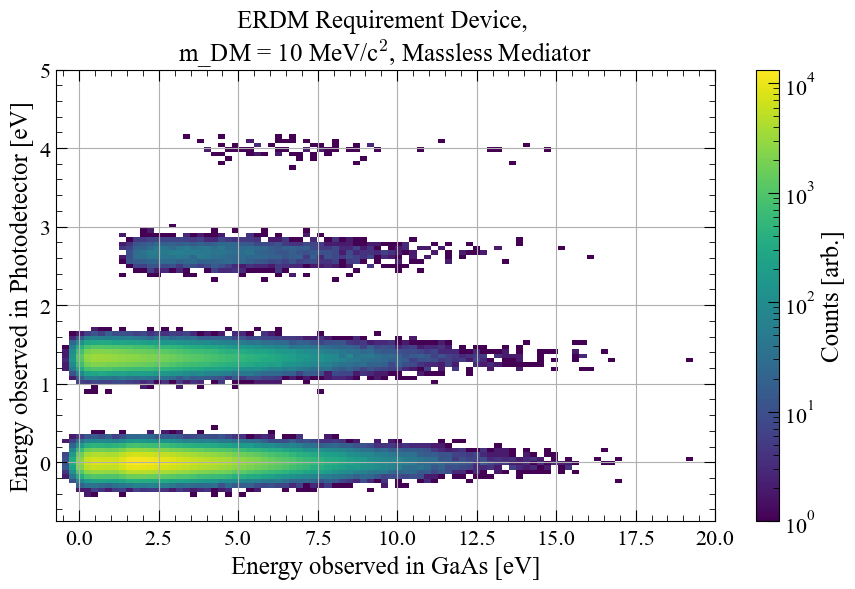

In [12]:
# ER Requirement
gaas_params = {'N_PDs': 1,
                'E_th_PD': 0.,
                'E_res_PD': 0.089e-3,
                'E_th_GaAs': 0.,
                'E_res_GaAs': 0.156e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.3}

mX_eV = 10e6

E_GaAs_bins, dRdE_GaAs_obs, E_recoil, N_eh, N_photons, N_photons_PD_A, N_photons_PD_B, \
    N_photons_sink, E_PD_A_keV, E_PD_B_keV, E_GaAs_keV, E_GaAs_obs_keV, fraction_in_GaAs, detected = \
        darklim.detector.DM_spectrum_GaAs(
            mX_eV, 1e-35, mediator='massless',
            e_high=0.3,
            N_PDs=gaas_params['N_PDs'],
            E_th_PD=gaas_params['E_th_PD'], E_res_PD=gaas_params['E_res_PD'],
            E_th_GaAs=gaas_params['E_th_GaAs'], E_res_GaAs=gaas_params['E_res_GaAs'],
            collection_efficiency=gaas_params['collection_efficiency'], GaAs_QE=0.6, GaAs_gamma_energy=gaas_params['GaAs_gamma_energy'],
            rng=np.random.default_rng(12345), n_sim=1_000_000, verbose=False, plot=False,
            verbose_return=True,
        )

# Plot the results in counts
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

# Plot the results in energy
h = ax.hist2d(E_GaAs_obs_keV*1e3, (E_PD_A_keV + E_PD_B_keV)*1e3, bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax, label='Counts [arb.]')

ax.set_xlabel('Energy observed in GaAs [eV]', fontsize=18)
ax.set_ylabel('Energy observed in Photodetector [eV]', fontsize=18)
ax.set_title(f'ERDM Requirement Device, \nm_DM = {mX_eV/1e6:.0f} MeV/c$^2$, Massless Mediator', fontsize=18)

ax.grid('on')
ax.set_ylim([-0.75, 5])
ax.set_xlim([-0.75, 20])

fig.tight_layout()
fig.show()

Mass = 0.5 GeV, 1.70e+04 evt/kg/day, 1.21e-04 above threshold
Mass = 1.0 GeV, 1.55e+04 evt/kg/day, 2.08e+03 above threshold
Mass = 2.0 GeV, 1.74e+04 evt/kg/day, 1.08e+04 above threshold
Mass = 10.0 GeV, 3.75e+04 evt/kg/day, 3.67e+04 above threshold

Mass = 0.5 GeV, 4.09e+02 evt/kg/day, 0.00e+00 above threshold
Mass = 1.0 GeV, 1.63e+03 evt/kg/day, 5.76e+02 above threshold
Mass = 2.0 GeV, 6.05e+03 evt/kg/day, 5.29e+03 above threshold
Mass = 10.0 GeV, 3.46e+04 evt/kg/day, 3.45e+04 above threshold


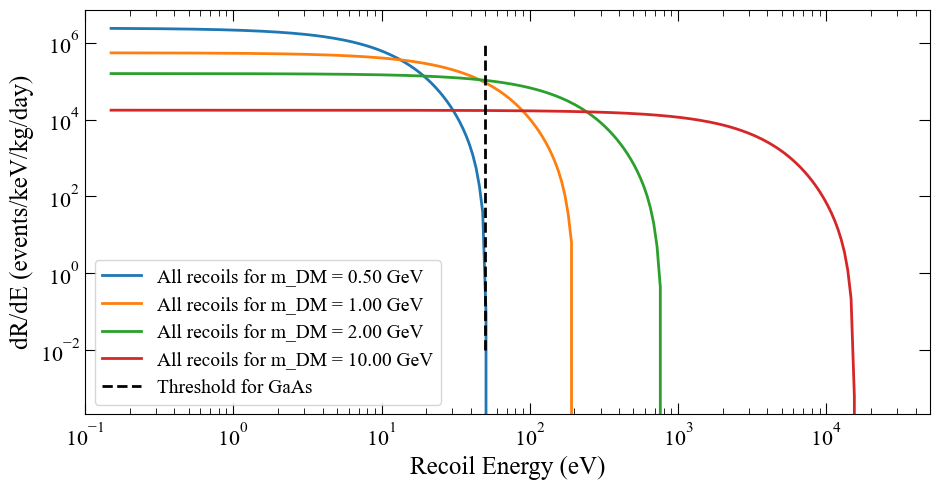

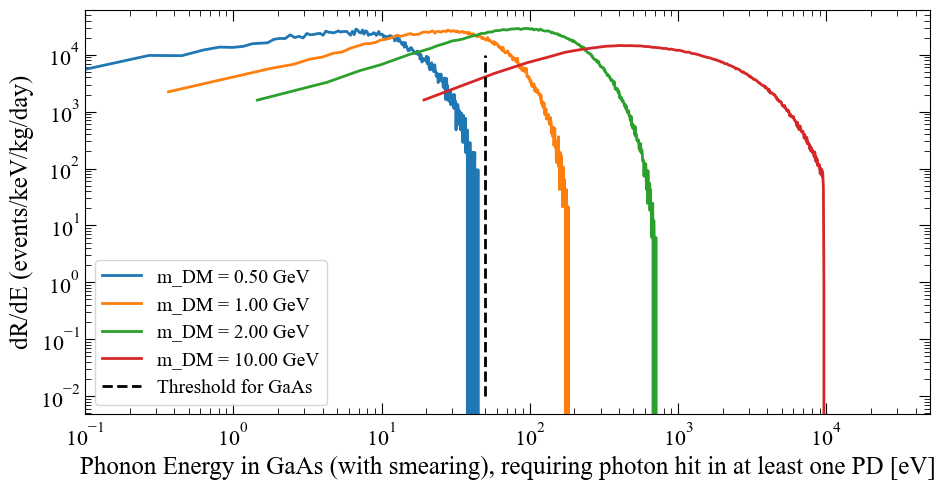

In [ ]:
gaas_params = {'N_PDs': 1,
                'E_th_PD': 1.2e-3,
                'E_res_PD': 0.042e-3,
                'E_th_GaAs': 0,
                'E_res_GaAs': 0.211e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.3}

fig, ax = plt.subplots(figsize=(9.5, 5))

for mX_eV in [500e6, 1e9, 2e9, 10e9]:
    mX_GeV = mX_eV / 1e9
    sigma0 = 1e-37

    E_keV_arr = np.geomspace(1.5e-4, 50, 250)

    ##################

    dRdE_arr = darklim.limit.drde(E_keV_arr, mX_GeV, sigma0, 'GaAs')

    ax.plot(E_keV_arr * 1e3, dRdE_arr, label=f'All recoils for m_DM = {mX_eV/1e9:.2f} GeV')
    
    cut = E_keV_arr > 50e-3

    print(f'Mass = {mX_GeV} GeV, {np.trapz(dRdE_arr, E_keV_arr):.2e} evt/kg/day, {np.trapz(dRdE_arr[cut], E_keV_arr[cut]):.2e} above threshold')

ax.plot([50, 50], [1e-2, 1e6], 'k--', lw=2, label='Threshold for GaAs')

ax.set_xscale('log')
ax.set_xlim([1e-1, 50e3])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)
fig.tight_layout()
fig.show()
print('')




fig, ax = plt.subplots(figsize=(9.5, 5))

for mX_eV in [500e6, 1e9, 2e9, 10e9]:
    mX_GeV = mX_eV / 1e9
    sigma0 = 1e-37

    ##################

    E_GaAs_arr_with_smearing, dRdE_GaAs_arr_with_smearing = \
        darklim.detector.DM_spectrum_GaAs(mX_eV, sigma0, mediator='NR', e_high=10.,
                            N_PDs = gaas_params['N_PDs'],
                            E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                            E_th_GaAs = 0., E_res_GaAs = gaas_params['E_res_GaAs'],
                            collection_efficiency=gaas_params['collection_efficiency'],
                            GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                            rng=np.random.default_rng(13819), n_sim = 1_000_000, verbose=False, plot=False)

    ax.plot(E_GaAs_arr_with_smearing * 1e3, dRdE_GaAs_arr_with_smearing, '-', lw=2, label=f'm_DM = {mX_eV/1e9:.2f} GeV')
    
    cut = E_GaAs_arr_with_smearing > 50e-3
    print(f'Mass = {mX_GeV} GeV, {np.trapz(dRdE_GaAs_arr_with_smearing, E_GaAs_arr_with_smearing):.2e} evt/kg/day, {np.trapz(dRdE_GaAs_arr_with_smearing[cut], E_GaAs_arr_with_smearing[cut]):.2e} above threshold')

ax.plot([50, 50], [1e-2, 1e4], 'k--', lw=2, label='Threshold for GaAs')

ax.set_xscale('log')
ax.set_xlim([1e-1, 50e3])
ax.set_yscale('log')
ax.set_xlabel(f'Phonon Energy in GaAs (with smearing), requiring photon hit in at least one PD [eV]')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)
fig.tight_layout()
fig.show()



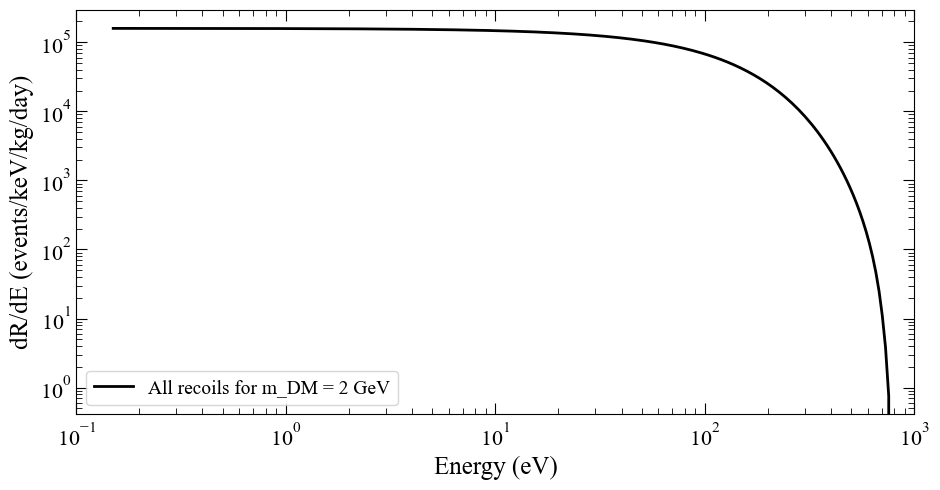

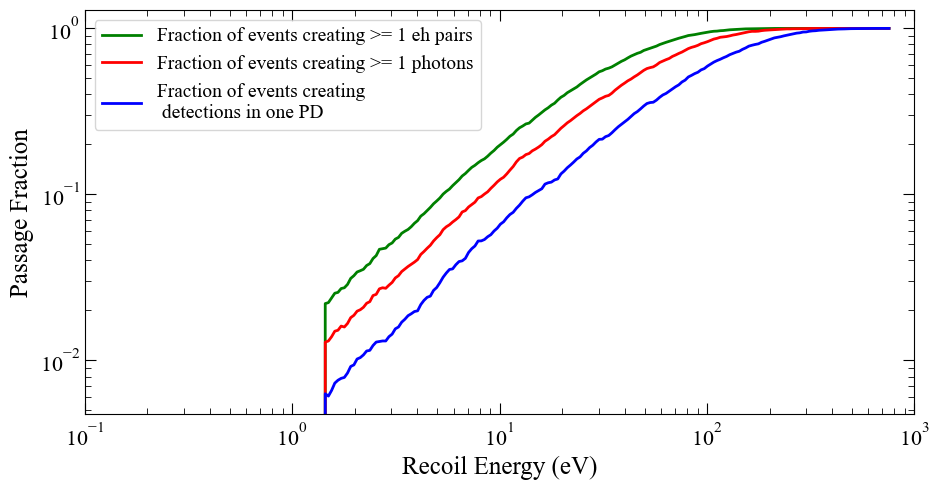

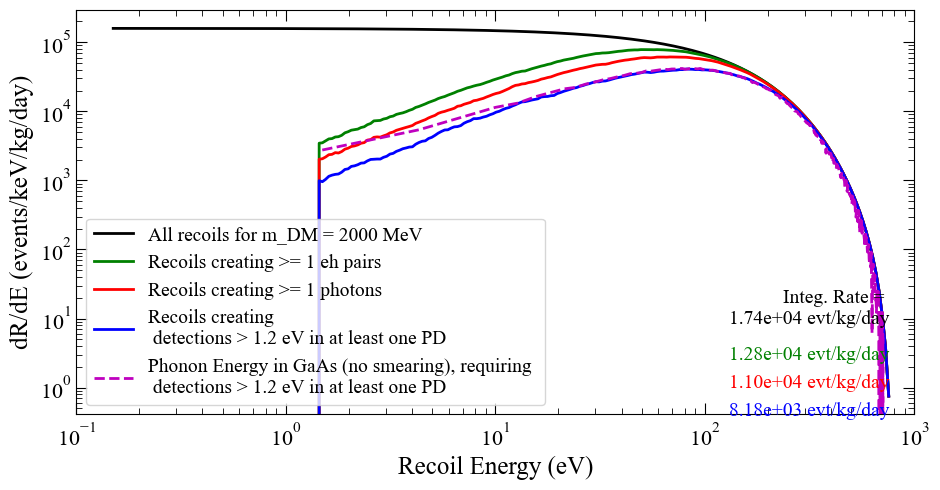

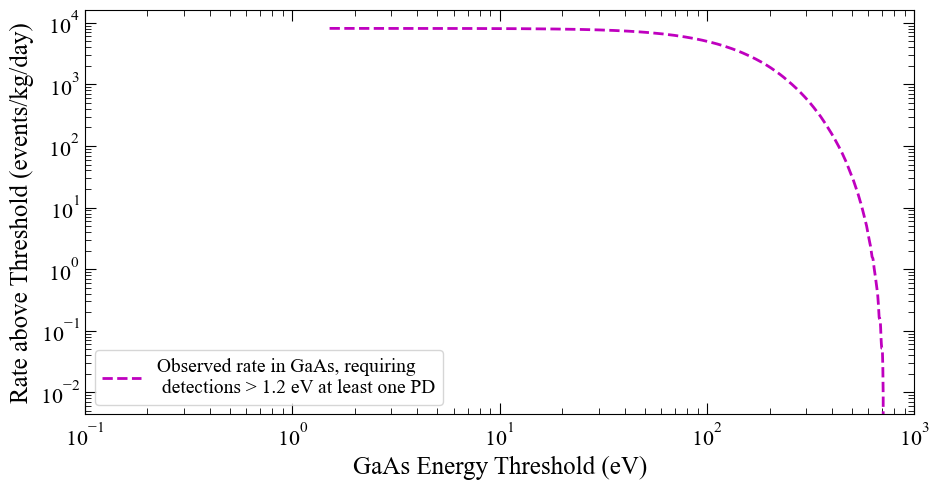

In [3]:
gaas_params = {'N_PDs': 1,
                'E_th_PD': 1.2e-3,
                'E_res_PD': 0.042e-3,
                'E_th_GaAs': 0,
                'E_res_GaAs': 0.211e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.5}

mX_eV = 2e9
mX_GeV = mX_eV / 1e9
sigma0 = 1e-37

E_keV_arr = np.geomspace(1.5e-4, 1, 250)

##################

fig, ax = plt.subplots(figsize=(9.5, 5))

dRdE_arr = darklim.limit.drde(E_keV_arr, mX_GeV, sigma0, 'GaAs')

ax.plot(E_keV_arr * 1e3, dRdE_arr, 'k-', label=f'All recoils for m_DM = {mX_eV/1e9:.0f} GeV')
    
ax.set_xscale('log')
ax.set_xlim([1e-1, 1e3])
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)
fig.tight_layout()
fig.show()

E_keV_ROI = E_keV_arr[dRdE_arr > 0]

##################

eff_1eh = np.zeros_like(E_keV_ROI)
eff_1photon = np.zeros_like(E_keV_ROI)
eff_1detected = np.zeros_like(E_keV_ROI)

for i, E_recoil in enumerate(E_keV_ROI):
    N_eh, N_photons, N_photons_PD_A, N_photons_PD_B, N_photons_sink, E_GaAs_keV, E_GaAs_obs_keV, E_PD_A_keV, E_PD_B_keV, detected, fraction_in_GaAs = \
        darklim.detector.monoenergetic_sim_GaAs(E_recoil, recoil = 'NR',
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = gaas_params['E_th_GaAs'], E_res_GaAs = gaas_params['E_res_GaAs'],
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(34567), n_sim = 10_000, verbose=False, verbose_return=True)

    eff_1eh[i] = sum(N_eh >= 1) / len(N_eh)
    eff_1photon[i] = sum(N_photons >= 1) / len(N_photons)
    eff_1detected[i] = sum((E_PD_A_keV > gaas_params['E_th_PD']) + (E_PD_B_keV > gaas_params['E_th_PD'])) / len(detected)

if i % 30 == 0:
        print(f'Completed {i} of {len(E_keV_ROI)} recoil energies')

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

ax.plot(E_keV_ROI * 1e3, eff_1eh, 'g-', lw=2, label=f'Fraction of events creating >= 1 eh pairs')
ax.plot(E_keV_ROI * 1e3, eff_1photon, 'r-', lw=2, label=f'Fraction of events creating >= 1 photons')
ax.plot(E_keV_ROI * 1e3, eff_1detected, 'b-', lw=2, label=f'Fraction of events creating \n detections in one PD')

ax.set_xscale('log')
ax.set_xlim([1e-1, 1e3])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Passage Fraction')
ax.legend(loc='upper left', fontsize=14)

fig.tight_layout()
fig.show()

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

cut = dRdE_arr > 0

ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut], 'k-', label=f'All recoils for m_DM = {mX_eV/1e6:.0f} MeV')
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_1eh, 'g-', lw=2, label=f'Recoils creating >= 1 eh pairs')
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_1photon, 'r-', lw=2, label=f'Recoils creating >= 1 photons')
E_th_PD = gaas_params['E_th_PD']
ax.plot(E_keV_ROI * 1e3, dRdE_arr[cut] * eff_1detected, 'b-', lw=2, label=f'Recoils creating \n detections > {E_th_PD*1e3:.1f} eV in at least one PD')

R_all = np.trapz(dRdE_arr[cut], E_keV_ROI)
ax.text(0.97, 0.31, f'Integ. Rate = \n{R_all:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='k')
R_2eh = np.trapz(dRdE_arr[cut] * eff_1eh, E_keV_ROI)
ax.text(0.97, 0.17, f'{R_2eh:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='g')
R_2photon = np.trapz(dRdE_arr[cut] * eff_1photon, E_keV_ROI)
ax.text(0.97, 0.10, f'{R_2photon:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='r')
R_detected = np.trapz(dRdE_arr[cut] * eff_1detected, E_keV_ROI)
ax.text(0.97, 0.03, f'{R_detected:.2e} evt/kg/day', ha='right', va='top', transform=ax.transAxes, fontsize=14, color='b')

E_GaAs_arr_no_smearing, dRdE_GaAs_arr_no_smearing = \
    darklim.detector.DM_spectrum_GaAs(mX_eV, sigma0, mediator='NR', e_high=1.,
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = 0., E_res_GaAs = 0.,
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(13819), n_sim = 1_000_000, verbose=False, plot=False)

E_GaAs_arr_with_smearing, dRdE_GaAs_arr_with_smearing = \
    darklim.detector.DM_spectrum_GaAs(mX_eV, sigma0, mediator='NR', e_high=1.,
                        N_PDs = gaas_params['N_PDs'],
                        E_th_PD = gaas_params['E_th_PD'], E_res_PD = gaas_params['E_res_PD'],
                        E_th_GaAs = 0., E_res_GaAs = gaas_params['E_res_GaAs'],
                        collection_efficiency=gaas_params['collection_efficiency'],
                        GaAs_QE=0.6, GaAs_gamma_energy=1.33e-3,
                        rng=np.random.default_rng(13819), n_sim = 1_000_000, verbose=False, plot=False)

ax.plot(E_GaAs_arr_no_smearing * 1e3, dRdE_GaAs_arr_no_smearing, 'm--', lw=2, label=f'Phonon Energy in GaAs (no smearing), requiring \n detections > {E_th_PD*1e3:.1f} eV in at least one PD')

ax.set_xscale('log')
ax.set_xlim([1e-1, 1e3])
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()

##################

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

R_above_threshold_arr = np.zeros_like(E_GaAs_arr_with_smearing)
for i, E_GaAs in enumerate(E_GaAs_arr_with_smearing):
    R_above_threshold_arr[i] = np.trapz(dRdE_GaAs_arr_with_smearing[(E_GaAs_arr_with_smearing >= E_GaAs)], E_GaAs_arr_with_smearing[(E_GaAs_arr_with_smearing >= E_GaAs)])

ax.plot(E_GaAs_arr_with_smearing * 1e3, R_above_threshold_arr, 'm--', lw=2, label=f'Observed rate in GaAs, requiring \n detections > {E_th_PD*1e3:.1f} eV at least one PD')

ax.set_xscale('log')
ax.set_xlim([1e-1, 1e3])
ax.set_yscale('log')
ax.set_xlabel('GaAs Energy Threshold (eV)')
ax.set_ylabel('Rate above Threshold (events/kg/day)')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()



In [6]:
# NR Requirement
gaas_params = {'N_PDs': 1,
                'E_th_PD': 1.33e-3 - 2 * 0.190e-3,
                'E_res_PD': 0.190e-3,
                'E_th_GaAs': 50e-3,
                'E_res_GaAs': 0.944e-3,
                'GaAs_gamma_energy': 1.33e-3,
                'collection_efficiency': 0.30}

mX_eV_arr = np.geomspace(30e6, 10e9, 30)
sigma0 = 1e-37

eff_1eh = np.zeros_like(mX_eV_arr)
eff_1photon = np.zeros_like(mX_eV_arr)
eff_1detected = np.zeros_like(mX_eV_arr)
eff_GaAs_detected = np.zeros_like(mX_eV_arr)

for i, mX_eV in enumerate(mX_eV_arr):

    E_GaAs_bins, dRdE_GaAs_obs, E_recoil, N_eh, N_photons, N_photons_PD_A, N_photons_PD_B, \
        N_photons_sink, E_PD_A_keV, E_PD_B_keV, E_GaAs_keV, E_GaAs_obs_keV, fraction_in_GaAs, detected = \
            darklim.detector.DM_spectrum_GaAs(
                mX_eV, sigma0, mediator='NR',
                e_high=100.,
                N_PDs=gaas_params['N_PDs'],
                E_th_PD=gaas_params['E_th_PD'], E_res_PD=gaas_params['E_res_PD'],
                E_th_GaAs=gaas_params['E_th_GaAs'], E_res_GaAs=gaas_params['E_res_GaAs'],
                collection_efficiency=gaas_params['collection_efficiency'], GaAs_QE=0.6, GaAs_gamma_energy=gaas_params['GaAs_gamma_energy'],
                rng=np.random.default_rng(12345 + i * 200), n_sim=1_000_000, verbose=False, plot=False,
                verbose_return=True,
            )

    eff_1eh[i] = sum(N_eh >= 1) / len(N_eh)
    eff_1photon[i] = sum(N_photons >= 1) / len(N_photons)
    
    pd_detected = (E_PD_A_keV > gaas_params['E_th_PD']) + (E_PD_B_keV > gaas_params['E_th_PD'])
    eff_1detected[i] = sum(pd_detected) / len(detected)
    eff_GaAs_detected[i] = sum(pd_detected * (E_GaAs_obs_keV > gaas_params['E_th_GaAs'])) / len(detected)

    print(f'Completed {i} of {len(mX_eV_arr)} masses')



Completed 0 of 30 masses
Completed 1 of 30 masses
Completed 2 of 30 masses
Completed 3 of 30 masses
Completed 4 of 30 masses
Completed 5 of 30 masses
Completed 6 of 30 masses
Completed 7 of 30 masses
Completed 8 of 30 masses
Completed 9 of 30 masses
Completed 10 of 30 masses
Completed 11 of 30 masses
Completed 12 of 30 masses
Completed 13 of 30 masses
Completed 14 of 30 masses
Completed 15 of 30 masses
Completed 16 of 30 masses
Completed 17 of 30 masses
Completed 18 of 30 masses
Completed 19 of 30 masses
Completed 20 of 30 masses
Completed 21 of 30 masses
Completed 22 of 30 masses
Completed 23 of 30 masses
Completed 24 of 30 masses
Completed 25 of 30 masses
Completed 26 of 30 masses
Completed 27 of 30 masses
Completed 28 of 30 masses
Completed 29 of 30 masses


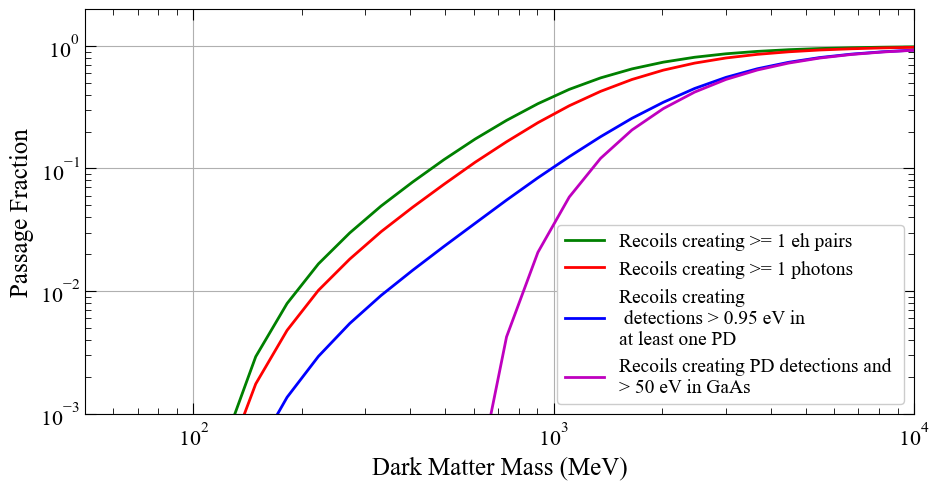

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))

ax.plot(mX_eV_arr / 1e6, eff_1eh, 'g-', lw=2, label=f'Recoils creating >= 1 eh pairs')
ax.plot(mX_eV_arr / 1e6, eff_1photon, 'r-', lw=2, label=f'Recoils creating >= 1 photons')
ax.plot(mX_eV_arr / 1e6, eff_1detected, 'b-', lw=2, label=f'Recoils creating \n detections > {gaas_params["E_th_PD"]*1e3:.2f} eV in \nat least one PD')
ax.plot(mX_eV_arr / 1e6, eff_GaAs_detected, 'm-', lw=2, label=f'Recoils creating PD detections and \n> {gaas_params["E_th_GaAs"]*1e3:.0f} eV in GaAs')

ax.set_xlim([5e1, 1e4])
ax.set_ylim([1e-3, 2e0])
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid('on')

ax.legend(loc='lower right', fontsize=14, framealpha=1)

ax.set_xlabel('Dark Matter Mass (MeV)')
ax.set_ylabel('Passage Fraction')

fig.tight_layout()
fig.show()


In [ ]:
fig, ax

In [4]:
x = darklim.detector.DM_spectrum_GaAs(
                mX_eV, sigma0, mediator='NR',
                e_high=100.,
                N_PDs=gaas_params['N_PDs'],
                E_th_PD=gaas_params['E_th_PD'], E_res_PD=gaas_params['E_res_PD'],
                E_th_GaAs=gaas_params['E_th_GaAs'], E_res_GaAs=gaas_params['E_res_GaAs'],
                collection_efficiency=gaas_params['collection_efficiency'], GaAs_QE=0.6, GaAs_gamma_energy=gaas_params['GaAs_gamma_energy'],
                rng=np.random.default_rng(12345 + i * 200), n_sim=1_000_000, verbose=False, plot=False,
                verbose_return=True,
            )

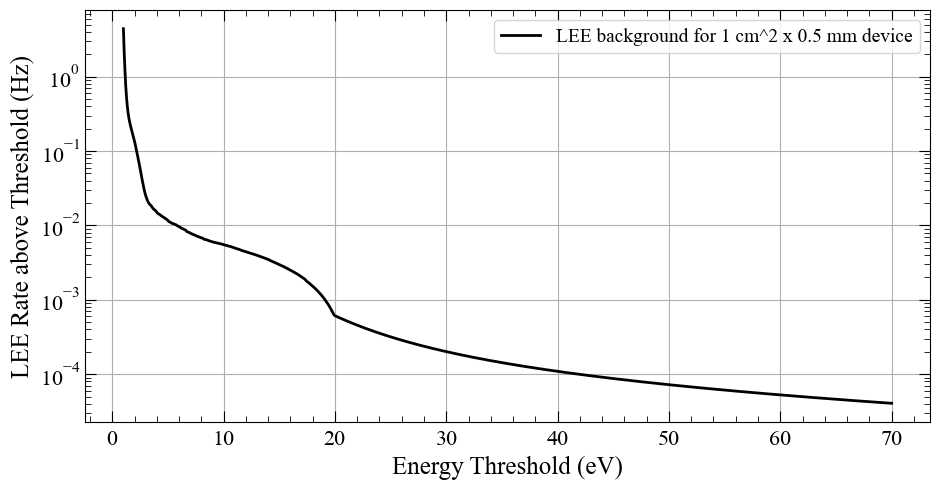

In [28]:
lee_input_file = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
lee_scale = 1. # From volume scaling

def run57_lee_bkgd():
    template = np.loadtxt(lee_input_file, skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400. * lee_scale)

E_LEE_cutoff_arr = np.linspace(1e-3, 70e-3, 1000)
R_LEE_above_threshold_arr = np.zeros_like(E_LEE_cutoff_arr)
for i, E_cutoff_GaAs in enumerate(E_LEE_cutoff_arr):
    E_max_GaAs = 500e-3
    E_arr_GaAs = np.geomspace(E_cutoff_GaAs, E_max_GaAs, 1000)
    dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs)
    R_LEE_above_threshold_arr[i] = np.trapz(dRdE_arr_GaAs, E_arr_GaAs)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_arr, 'k-', lw=2, label=f'LEE background for 1 cm^2 x 0.5 mm device')
ax.set_yscale('log')
ax.set_xlabel('Energy Threshold (eV)')
ax.set_ylabel('LEE Rate above Threshold (Hz)')
ax.legend(loc='upper right', fontsize=14)
ax.grid('on')
fig.tight_layout()
fig.show()

In [29]:
E_min_CDR = 2e-3
E_max_CDR = 20e-3

###############
# ER Requirement #
###############

print('ER Requirement:')
PD_area_mm2 = 49.
PD_thickness_mm = 0.3
PD_volume_cm3 = PD_area_mm2 * PD_thickness_mm / 1000
PD_LEE_improvement = 1.
LEE_volume_scale = PD_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_PD = 0.0886e-3
E_th_PD = 1.33e-3 - 0 * E_res_PD

R_LEE_PD = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * LEE_volume_scale / PD_LEE_improvement
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_LEE_PD:.2e} Hz')

R_LEE_range_PD = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in PD: {R_LEE_range_PD*LEE_volume_scale/PD_LEE_improvement/PD_volume_cm3:.2e} Hz/cm^3')

GaAs_area_mm2 = PD_area_mm2
GaAs_thickness_mm = 0.5
GaAs_volume_cm3 = GaAs_area_mm2 * GaAs_thickness_mm / 1000
GaAs_LEE_improvement = 1.
GaAs_LEE_volume_scale = GaAs_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_GaAs = 0.1558e-3
E_th_GaAs = 3e-3

R_LEE_GaAs = np.interp(E_th_GaAs, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * GaAs_LEE_volume_scale / GaAs_LEE_improvement
print(f'LEE rate above {E_th_GaAs*1e3:.3f} eV in GaAs: {R_LEE_GaAs:.2e} Hz')

R_LEE_range_GaAs = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in GaAs: {R_LEE_range_GaAs*GaAs_LEE_volume_scale/GaAs_LEE_improvement/GaAs_volume_cm3:.2e} Hz/cm^3')

coincident_window_s = 30e-6 
exposure_days = 300
n_modules = 12
R_LEE_coincident = R_LEE_PD * R_LEE_GaAs * coincident_window_s * 86400 * exposure_days * n_modules
print(f'In a {exposure_days} day exposure with {n_modules} modules, the coincident LEE rate is {R_LEE_coincident:.2e} events')
print('')

###############
# NR Requirement #
###############

print('NR Requirement:')
PD_area_mm2 = 225.
PD_thickness_mm = 0.3
PD_volume_cm3 = PD_area_mm2 * PD_thickness_mm / 1000
LEE_volume_scale = PD_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_PD = 0.1898e-3
E_th_PD = 1.33e-3 - 0 * E_res_PD

R_LEE_PD = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * LEE_volume_scale
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_LEE_PD:.2e} Hz')

R_LEE_range_PD = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in PD: {R_LEE_range_PD*LEE_volume_scale/PD_LEE_improvement/PD_volume_cm3:.2e} Hz/cm^3')

GaAs_area_mm2 = PD_area_mm2
GaAs_thickness_mm = 4.
GaAs_volume_cm3 = GaAs_area_mm2 * GaAs_thickness_mm / 1000
GaAs_LEE_volume_scale = GaAs_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_GaAs = 0.9442e-3
E_th_GaAs = 50e-3

R_LEE_GaAs = np.interp(E_th_GaAs, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * GaAs_LEE_volume_scale
print(f'LEE rate above {E_th_GaAs*1e3:.3f} eV in GaAs: {R_LEE_GaAs:.2e} Hz')

R_LEE_range_GaAs = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in GaAs: {R_LEE_range_GaAs*GaAs_LEE_volume_scale/GaAs_LEE_improvement/GaAs_volume_cm3:.2e} Hz/cm^3')

coincident_window_s = 30e-6 
exposure_days = 300
n_modules = 12
R_LEE_coincident = R_LEE_PD * R_LEE_GaAs * coincident_window_s * 86400 * exposure_days * n_modules
print(f'In a {exposure_days} day exposure with {n_modules} modules, the coincident LEE rate is {R_LEE_coincident:.2e} events')
print('')

###############
# ER Goal #
###############

print('ER Goal:')
PD_area_mm2 = 225.
PD_thickness_mm = 0.3
PD_volume_cm3 = PD_area_mm2 * PD_thickness_mm / 1000
PD_LEE_improvement = 20.
LEE_volume_scale = PD_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_PD = 0.042e-3
E_th_PD = 1.33e-3 - 0 * E_res_PD

R_LEE_PD = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * LEE_volume_scale / PD_LEE_improvement
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_LEE_PD:.2e} Hz')

R_LEE_range_PD = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in PD: {R_LEE_range_PD*LEE_volume_scale/PD_LEE_improvement/PD_volume_cm3:.2e} Hz/cm^3')

GaAs_area_mm2 = PD_area_mm2
GaAs_thickness_mm = 4.
GaAs_volume_cm3 = GaAs_area_mm2 * GaAs_thickness_mm / 1000
GaAs_LEE_improvement = 20.
GaAs_LEE_volume_scale = GaAs_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_GaAs = 0.211e-3
E_th_GaAs = 3e-3

R_LEE_GaAs = np.interp(E_th_GaAs, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * GaAs_LEE_volume_scale / GaAs_LEE_improvement
print(f'LEE rate above {E_th_GaAs*1e3:.3f} eV in GaAs: {R_LEE_GaAs:.2e} Hz')

R_LEE_range_GaAs = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in GaAs: {R_LEE_range_GaAs*GaAs_LEE_volume_scale/GaAs_LEE_improvement/GaAs_volume_cm3:.2e} Hz/cm^3')

coincident_window_s = 30e-6 
exposure_days = 300
n_modules = 12
R_LEE_coincident = R_LEE_PD * R_LEE_GaAs * coincident_window_s * 86400 * exposure_days * n_modules
print(f'In a {exposure_days} day exposure with {n_modules} modules, the coincident LEE rate is {R_LEE_coincident:.2e} events')
print('')

###############
# NR Goal #
###############

print('NR Goal:')
PD_area_mm2 = 400.
PD_thickness_mm = 0.3
PD_volume_cm3 = PD_area_mm2 * PD_thickness_mm / 1000
PD_LEE_improvement = 20.
LEE_volume_scale = PD_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_PD = 0.056e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD

R_LEE_PD = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * LEE_volume_scale / PD_LEE_improvement
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_LEE_PD:.2e} Hz')

R_LEE_range_PD = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in PD: {R_LEE_range_PD*LEE_volume_scale/PD_LEE_improvement/PD_volume_cm3:.2e} Hz/cm^3')

GaAs_area_mm2 = PD_area_mm2
GaAs_thickness_mm = 12.
GaAs_volume_cm3 = GaAs_area_mm2 * GaAs_thickness_mm / 1000
GaAs_LEE_improvement = 20.
GaAs_LEE_volume_scale = GaAs_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_GaAs = 0.487e-3
E_th_GaAs = 20e-3

R_LEE_GaAs = np.interp(E_th_GaAs, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * GaAs_LEE_volume_scale / GaAs_LEE_improvement
print(f'LEE rate above {E_th_GaAs*1e3:.3f} eV in GaAs: {R_LEE_GaAs:.2e} Hz')

R_LEE_range_GaAs = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in GaAs: {R_LEE_range_GaAs*GaAs_LEE_volume_scale/GaAs_LEE_improvement/GaAs_volume_cm3:.2e} Hz/cm^3')

coincident_window_s = 30e-6 
exposure_days = 300
n_modules = 12
R_LEE_coincident = R_LEE_PD * R_LEE_GaAs * coincident_window_s * 86400 * exposure_days * n_modules
print(f'In a {exposure_days} day exposure with {n_modules} modules, the coincident LEE rate is {R_LEE_coincident:.2e} events')
print('')

###############
# ER Stretch #
###############

print('ER Stretch:')
PD_area_mm2 = 900.
PD_thickness_mm = 0.3
PD_volume_cm3 = PD_area_mm2 * PD_thickness_mm / 1000
PD_LEE_improvement = 400.
LEE_volume_scale = PD_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_PD = 0.019e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD

R_LEE_PD = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * LEE_volume_scale / PD_LEE_improvement
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_LEE_PD:.2e} Hz')

R_LEE_range_PD = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in PD: {R_LEE_range_PD*LEE_volume_scale/PD_LEE_improvement/PD_volume_cm3:.2e} Hz/cm^3')

GaAs_area_mm2 = PD_area_mm2
GaAs_thickness_mm = 12.
GaAs_volume_cm3 = GaAs_area_mm2 * GaAs_thickness_mm / 1000
GaAs_LEE_improvement = 400.
GaAs_LEE_volume_scale = GaAs_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_GaAs = 0.163e-3
E_th_GaAs = 3e-3

R_LEE_GaAs = np.interp(E_th_GaAs, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * GaAs_LEE_volume_scale / GaAs_LEE_improvement
print(f'LEE rate above {E_th_GaAs*1e3:.3f} eV in GaAs: {R_LEE_GaAs:.2e} Hz')

R_LEE_range_GaAs = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in GaAs: {R_LEE_range_GaAs*GaAs_LEE_volume_scale/GaAs_LEE_improvement/GaAs_volume_cm3:.2e} Hz/cm^3')

coincident_window_s = 30e-6 
exposure_days = 300
n_modules = 12
R_LEE_coincident = R_LEE_PD * R_LEE_GaAs * coincident_window_s * 86400 * exposure_days * n_modules
print(f'In a {exposure_days} day exposure with {n_modules} modules, the coincident LEE rate is {R_LEE_coincident:.2e} events')
print('')

###############
# NR Stretch #
###############

print('NR Stretch:')
PD_area_mm2 = 900.
PD_thickness_mm = 0.3
PD_volume_cm3 = PD_area_mm2 * PD_thickness_mm / 1000
PD_LEE_improvement = 400.
LEE_volume_scale = PD_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_PD = 0.019e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD

R_LEE_PD = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * LEE_volume_scale / PD_LEE_improvement
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_LEE_PD:.2e} Hz')

R_LEE_range_PD = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in PD: {R_LEE_range_PD*LEE_volume_scale/PD_LEE_improvement/PD_volume_cm3:.2e} Hz/cm^3')

GaAs_area_mm2 = PD_area_mm2
GaAs_thickness_mm = 12.
GaAs_volume_cm3 = GaAs_area_mm2 * GaAs_thickness_mm / 1000
GaAs_LEE_improvement = 400.
GaAs_LEE_volume_scale = GaAs_volume_cm3 / (1 * 0.1)  # Scale from 1 cm^2 x 1 mm

E_res_GaAs = 0.163e-3
E_th_GaAs = 3e-3

R_LEE_GaAs = np.interp(E_th_GaAs, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) * GaAs_LEE_volume_scale / GaAs_LEE_improvement
print(f'LEE rate above {E_th_GaAs*1e3:.3f} eV in GaAs: {R_LEE_GaAs:.2e} Hz')

R_LEE_range_GaAs = np.interp(E_min_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr) - np.interp(E_max_CDR, E_LEE_cutoff_arr, R_LEE_above_threshold_arr)
print(f'LEE rate in CDR range ({E_min_CDR*1e3:.1f}-{E_max_CDR*1e3:.1f} eV) in GaAs: {R_LEE_range_GaAs*GaAs_LEE_volume_scale/GaAs_LEE_improvement/GaAs_volume_cm3:.2e} Hz/cm^3')

coincident_window_s = 30e-6 
exposure_days = 300
n_modules = 12
R_LEE_coincident = R_LEE_PD * R_LEE_GaAs * coincident_window_s * 86400 * exposure_days * n_modules
print(f'In a {exposure_days} day exposure with {n_modules} modules, the coincident LEE rate is {R_LEE_coincident:.2e} events')
print('')


ER Requirement:
LEE rate above 1.330 eV in PD: 6.41e-02 Hz
LEE rate in CDR range (2.0-20.0 eV) in PD: 1.34e+00 Hz/cm^3
LEE rate above 3.000 eV in GaAs: 6.19e-03 Hz
LEE rate in CDR range (2.0-20.0 eV) in GaAs: 1.34e+00 Hz/cm^3
In a 300 day exposure with 12 modules, the coincident LEE rate is 3.70e+00 events

NR Requirement:
LEE rate above 1.330 eV in PD: 2.94e-01 Hz
LEE rate in CDR range (2.0-20.0 eV) in PD: 1.34e+00 Hz/cm^3
LEE rate above 50.000 eV in GaAs: 6.51e-04 Hz
LEE rate in CDR range (2.0-20.0 eV) in GaAs: 1.34e+00 Hz/cm^3
In a 300 day exposure with 12 modules, the coincident LEE rate is 1.79e+00 events

ER Goal:
LEE rate above 1.330 eV in PD: 1.47e-02 Hz
LEE rate in CDR range (2.0-20.0 eV) in PD: 6.70e-02 Hz/cm^3
LEE rate above 3.000 eV in GaAs: 1.14e-02 Hz
LEE rate in CDR range (2.0-20.0 eV) in GaAs: 6.70e-02 Hz/cm^3
In a 300 day exposure with 12 modules, the coincident LEE rate is 1.56e+00 events

NR Goal:
LEE rate above 1.218 eV in PD: 4.38e-02 Hz
LEE rate in CDR range (2.0-

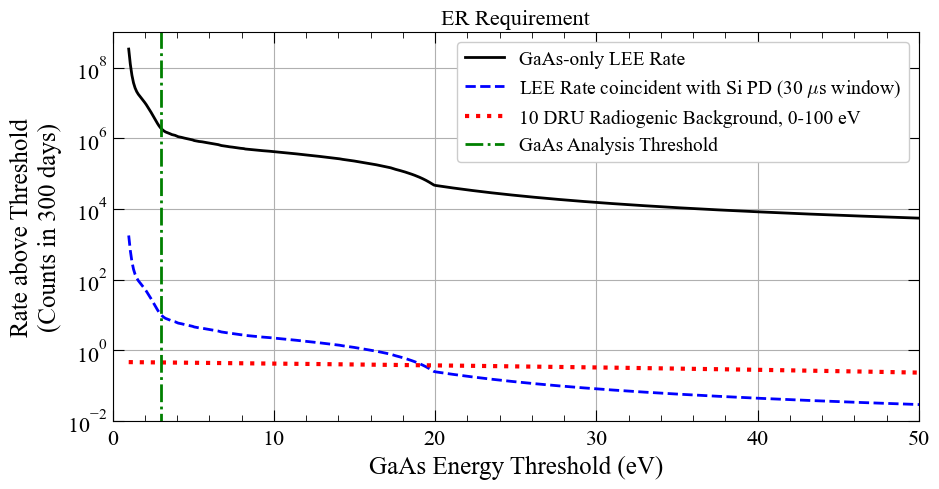

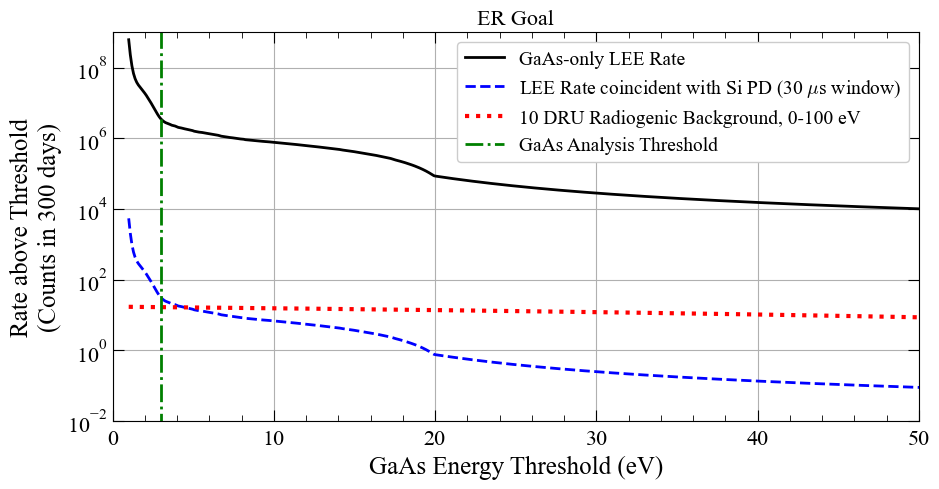

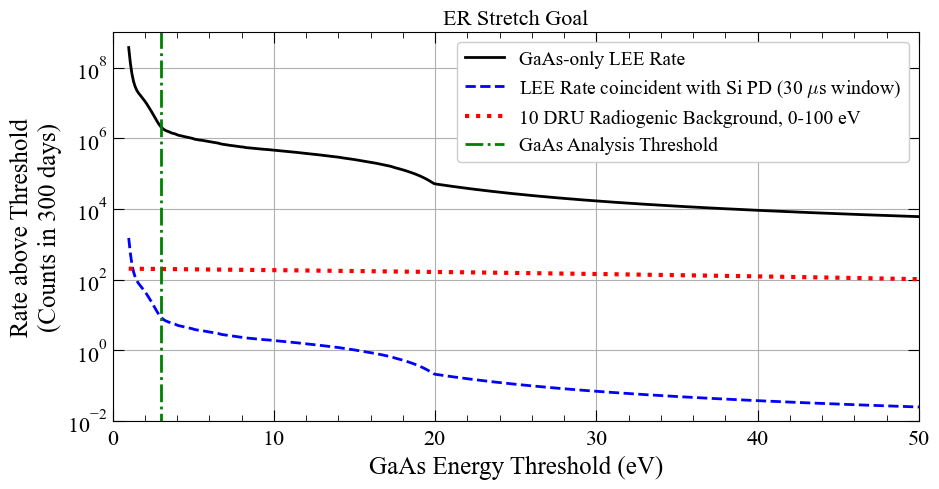

In [ ]:
lee_input_file = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
lee_scale = 1. # From volume scaling

def run57_lee_bkgd():
    template = np.loadtxt(lee_input_file, skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400. * lee_scale)

##################
# ER Requirement #
##################

E_LEE_cutoff_arr = np.linspace(1e-3, 100e-3, 1000)
R_LEE_above_threshold_Hz = np.zeros_like(E_LEE_cutoff_arr)
GaAs_volume_scale = 49 * 0.5 / 100
for i, E_cutoff_GaAs in enumerate(E_LEE_cutoff_arr):
    E_max_GaAs = 500e-3
    E_arr_GaAs = np.geomspace(E_cutoff_GaAs, E_max_GaAs, 1000)
    dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs)
    R_LEE_above_threshold_Hz[i] = np.trapz(dRdE_arr_GaAs, E_arr_GaAs)
R_LEE_above_threshold_GaAs_Hz = R_LEE_above_threshold_Hz * GaAs_volume_scale / 1

E_res_PD = 0.089e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD
PD_volume_scale = 49 * 0.3 / 100
R_LEE_above_threshold_PD_Hz = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_Hz) * PD_volume_scale / 1

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_GaAs_Hz * 86400 * 300 * 12, 'k-', lw=2, label=f'GaAs-only LEE Rate')
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_GaAs_Hz * R_LEE_above_threshold_PD_Hz * 30e-6 * 86400 * 300 * 12, 'b--', lw=2, label=f'LEE Rate coincident with Si PD (30 $\mu$s window)')

GaAs_mass_kg = GaAs_volume_scale / 10 * 5.32e-3 * 12
R_radiogenic = 10 * 300 * GaAs_mass_kg * 0.1  # Target radiogenic background in 300 days, 0.1 keV window
ax.plot(E_LEE_cutoff_arr * 1e3, R_radiogenic * (100 - E_LEE_cutoff_arr * 1e3) / 100, 'r:', lw=3, label=f'10 DRU Radiogenic Background, 0-100 eV')

ax.plot([3, 3], [1e-4, 1e9], 'g-.', lw=2, label='GaAs Analysis Threshold')

ax.set_yscale('log')
ax.set_xlim([0, 50])
ax.set_ylim([1e-2, 1e9])
ax.set_xlabel('GaAs Energy Threshold (eV)')
ax.set_ylabel('Rate above Threshold\n(Counts in 300 days)')
ax.set_title('ER Requirement', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()


##################
# ER Goal #
##################

E_LEE_cutoff_arr = np.linspace(1e-3, 100e-3, 1000)
R_LEE_above_threshold_Hz = np.zeros_like(E_LEE_cutoff_arr)
GaAs_volume_scale = 225 * 4 / 100
for i, E_cutoff_GaAs in enumerate(E_LEE_cutoff_arr):
    E_max_GaAs = 500e-3
    E_arr_GaAs = np.geomspace(E_cutoff_GaAs, E_max_GaAs, 1000)
    dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs)
    R_LEE_above_threshold_Hz[i] = np.trapz(dRdE_arr_GaAs, E_arr_GaAs)
R_LEE_above_threshold_GaAs_Hz = R_LEE_above_threshold_Hz * GaAs_volume_scale / 20

E_res_PD = 0.042e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD
PD_volume_scale = 225 * 4 / 100
R_LEE_above_threshold_PD_Hz = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_Hz) * PD_volume_scale / 20

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_GaAs_Hz * 86400 * 300 * 12, 'k-', lw=2, label=f'GaAs-only LEE Rate')
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_GaAs_Hz * R_LEE_above_threshold_PD_Hz * 30e-6 * 86400 * 300 * 12, 'b--', lw=2, label=f'LEE Rate coincident with Si PD (30 $\mu$s window)')

GaAs_mass_kg = GaAs_volume_scale / 10 * 5.32e-3 * 12
R_radiogenic = 10 * 300 * GaAs_mass_kg * 0.1  # Target radiogenic background in 300 days, 0.1 keV window
ax.plot(E_LEE_cutoff_arr * 1e3, R_radiogenic * (100 - E_LEE_cutoff_arr * 1e3) / 100, 'r:', lw=3, label=f'10 DRU Radiogenic Background, 0-100 eV')

ax.plot([3, 3], [1e-4, 1e9], 'g-.', lw=2, label='GaAs Analysis Threshold')

ax.set_yscale('log')
ax.set_xlim([0, 50])
ax.set_ylim([1e-2, 1e9])
ax.set_xlabel('GaAs Energy Threshold (eV)')
ax.set_ylabel('Rate above Threshold\n(Counts in 300 days)')
ax.set_title('ER Goal', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()


##################
# ER Stretch Goal #
##################

E_LEE_cutoff_arr = np.linspace(1e-3, 100e-3, 1000)
R_LEE_above_threshold_Hz = np.zeros_like(E_LEE_cutoff_arr)
GaAs_volume_scale = 900 * 12 / 100
for i, E_cutoff_GaAs in enumerate(E_LEE_cutoff_arr):
    E_max_GaAs = 500e-3
    E_arr_GaAs = np.geomspace(E_cutoff_GaAs, E_max_GaAs, 1000)
    dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs)
    R_LEE_above_threshold_Hz[i] = np.trapz(dRdE_arr_GaAs, E_arr_GaAs)
R_LEE_above_threshold_GaAs_Hz = R_LEE_above_threshold_Hz * GaAs_volume_scale / 400

E_res_PD = 0.019e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD
PD_volume_scale = 900 * 12 / 100
R_LEE_above_threshold_PD_Hz = np.interp(E_th_PD, E_LEE_cutoff_arr, R_LEE_above_threshold_Hz) * PD_volume_scale / 400

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_GaAs_Hz * 86400 * 300 * 12, 'k-', lw=2, label=f'GaAs-only LEE Rate')
ax.plot(E_LEE_cutoff_arr * 1e3, R_LEE_above_threshold_GaAs_Hz * R_LEE_above_threshold_PD_Hz * 30e-6 * 86400 * 300 * 12, 'b--', lw=2, label=f'LEE Rate coincident with Si PD (30 $\mu$s window)')

GaAs_mass_kg = GaAs_volume_scale / 10 * 5.32e-3 * 12
R_radiogenic = 10 * 300 * GaAs_mass_kg * 0.1  # Target radiogenic background in 300 days, 0.1 keV window
ax.plot(E_LEE_cutoff_arr * 1e3, R_radiogenic * (100 - E_LEE_cutoff_arr * 1e3) / 100, 'r:', lw=3, label=f'10 DRU Radiogenic Background, 0-100 eV')

ax.plot([3, 3], [1e-4, 1e9], 'g-.', lw=2, label='GaAs Analysis Threshold')

ax.set_yscale('log')
ax.set_xlim([0, 50])
ax.set_ylim([1e-2, 1e9])
ax.set_xlabel('GaAs Energy Threshold (eV)')
ax.set_ylabel('Rate above Threshold\n(Counts in 300 days)')
ax.set_title('ER Stretch Goal', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()


LEE rate above 3 eV in GaAs coincident with PD: 9.32 counts in 300 days
LEE rate above 3 eV in GaAs coincident with PD: 2.21 counts in 300 days
LEE rate above 3 eV in GaAs coincident with PD: 0.21 counts in 300 days


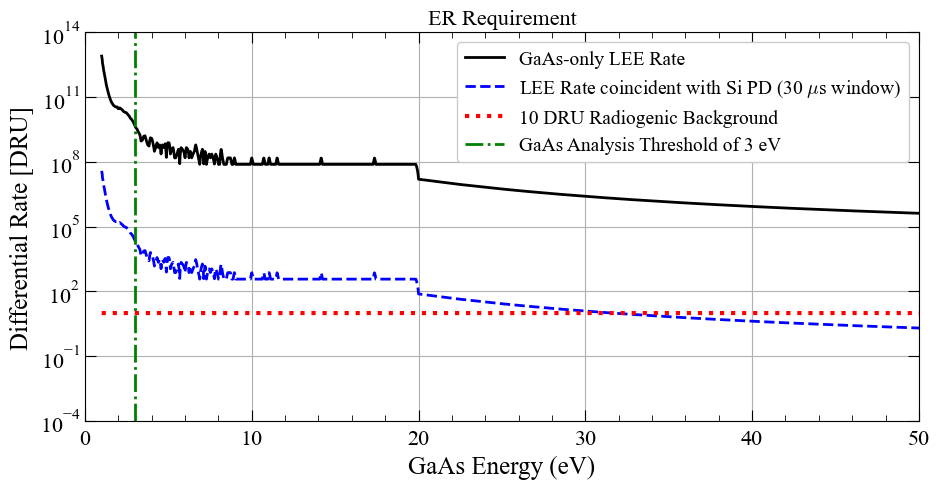

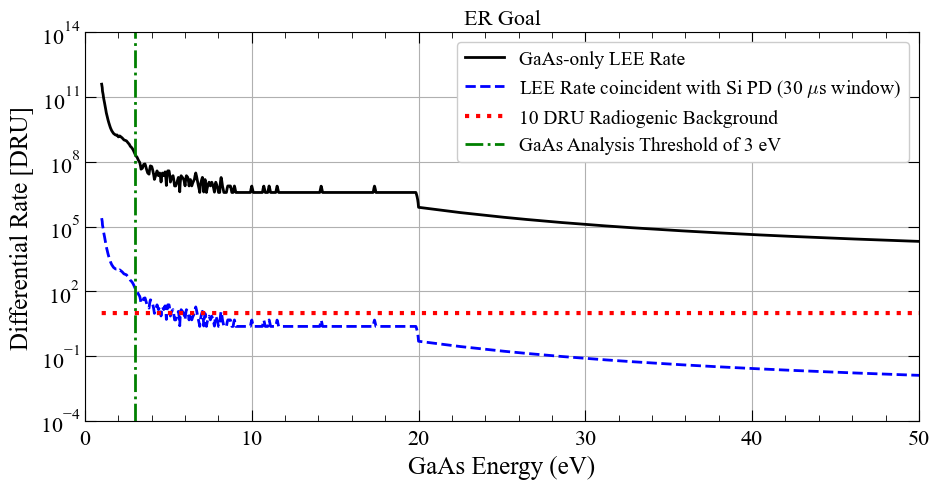

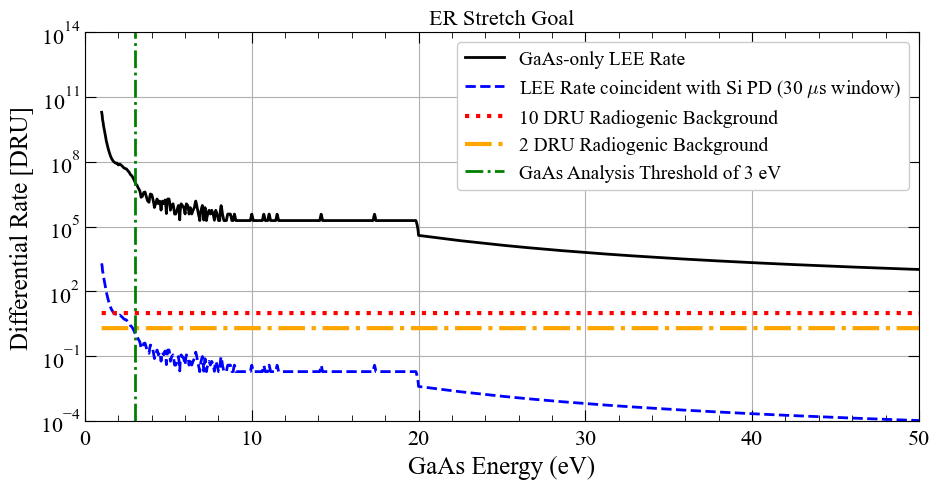

In [44]:
lee_input_file = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
lee_scale = 1. # From volume scaling

def run57_lee_bkgd():
    template = np.loadtxt(lee_input_file, skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400. * lee_scale)


##################
# ER Requirement #
##################

E_arr_GaAs = np.geomspace(1e-3, 500e-3, 10_000)
GaAs_volume_scale = 49 * 0.5 / 100
GaAs_volume_cm3 = GaAs_volume_scale / 10
GaAs_mass_kg = GaAs_volume_cm3 * 5.32e-3

dRdE_arr_LEE = run57_lee_bkgd()(E_arr_GaAs) # Units of Hz/keV
dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs) * GaAs_volume_scale / GaAs_mass_kg * 86400. # Units of DRU
dRdE_arr_GaAs /= 1. # Improvement factor

E_res_PD = 0.089e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD
PD_volume_scale = 49 * 0.3 / 100
R_LEE_above_threshold_PD_Hz = np.trapz(dRdE_arr_LEE[E_arr_GaAs >= E_th_PD], E_arr_GaAs[E_arr_GaAs >= E_th_PD]) * PD_volume_scale / 1. # Units of Hz

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_arr_GaAs * 1e3, dRdE_arr_GaAs, 'k-', lw=2, label=f'GaAs-only LEE Rate')
ax.plot(E_arr_GaAs * 1e3, dRdE_arr_GaAs * R_LEE_above_threshold_PD_Hz * 30e-6, 'b--', lw=2, label=f'LEE Rate coincident with Si PD (30 $\mu$s window)')
y = dRdE_arr_GaAs * R_LEE_above_threshold_PD_Hz * 30e-6
x = E_arr_GaAs
cut = x >= 3e-3
R = np.trapz(y[cut], x[cut]) * 300 * GaAs_mass_kg * 12
print(f'LEE rate above 3 eV in GaAs coincident with PD: {R:.2f} counts in 300 days')

ax.plot(E_arr_GaAs * 1e3, np.full_like(E_arr_GaAs, 10), 'r:', lw=3, label=f'10 DRU Radiogenic Background')

ax.plot([3, 3], [1e-4, 1e14], 'g-.', lw=2, label='GaAs Analysis Threshold of 3 eV')

ax.set_yscale('log')
ax.set_xlim([0, 50])
ax.set_ylim([1e-4, 1e14])
ax.set_xlabel('GaAs Energy (eV)')
ax.set_ylabel('Differential Rate [DRU]')
ax.set_title('ER Requirement', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()


##################
# ER Goal        #
##################

E_arr_GaAs = np.geomspace(1e-3, 500e-3, 10_000)
GaAs_volume_scale = 225 * 4 / 100
GaAs_volume_cm3 = GaAs_volume_scale / 10
GaAs_mass_kg = GaAs_volume_cm3 * 5.32e-3

dRdE_arr_LEE = run57_lee_bkgd()(E_arr_GaAs) # Units of Hz/keV
dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs) * GaAs_volume_scale / GaAs_mass_kg * 86400. # Units of DRU
dRdE_arr_GaAs /= 20. # Improvement factor

E_res_PD = 0.042e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD
PD_volume_scale = 225 * 0.3 / 100
R_LEE_above_threshold_PD_Hz = np.trapz(dRdE_arr_LEE[E_arr_GaAs >= E_th_PD], E_arr_GaAs[E_arr_GaAs >= E_th_PD]) * PD_volume_scale / 20. # Units of Hz

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_arr_GaAs * 1e3, dRdE_arr_GaAs, 'k-', lw=2, label=f'GaAs-only LEE Rate')
ax.plot(E_arr_GaAs * 1e3, dRdE_arr_GaAs * R_LEE_above_threshold_PD_Hz * 30e-6, 'b--', lw=2, label=f'LEE Rate coincident with Si PD (30 $\mu$s window)')
y = dRdE_arr_GaAs * R_LEE_above_threshold_PD_Hz * 30e-6
x = E_arr_GaAs
cut = x >= 3e-3
R = np.trapz(y[cut], x[cut]) * 300 * GaAs_mass_kg * 12
print(f'LEE rate above 3 eV in GaAs coincident with PD: {R:.2f} counts in 300 days')

ax.plot(E_arr_GaAs * 1e3, np.full_like(E_arr_GaAs, 10), 'r:', lw=3, label=f'10 DRU Radiogenic Background')

ax.plot([3, 3], [1e-4, 1e14], 'g-.', lw=2, label='GaAs Analysis Threshold of 3 eV')

ax.set_yscale('log')
ax.set_xlim([0, 50])
ax.set_ylim([1e-4, 1e14])
ax.set_xlabel('GaAs Energy (eV)')
ax.set_ylabel('Differential Rate [DRU]')
ax.set_title('ER Goal', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()


##################
# ER Stretch Goal #
##################

E_arr_GaAs = np.geomspace(1e-3, 500e-3, 10_000)
GaAs_volume_scale = 900 * 12 / 100
GaAs_volume_cm3 = GaAs_volume_scale / 10
GaAs_mass_kg = GaAs_volume_cm3 * 5.32e-3

dRdE_arr_LEE = run57_lee_bkgd()(E_arr_GaAs) # Units of Hz/keV
dRdE_arr_GaAs = run57_lee_bkgd()(E_arr_GaAs) * GaAs_volume_scale / GaAs_mass_kg * 86400. # Units of DRU
dRdE_arr_GaAs /= 400. # Improvement factor

E_res_PD = 0.019e-3
E_th_PD = 1.33e-3 - 2 * E_res_PD
PD_volume_scale = 900 * 0.3 / 100
R_LEE_above_threshold_PD_Hz = np.trapz(dRdE_arr_LEE[E_arr_GaAs >= E_th_PD], E_arr_GaAs[E_arr_GaAs >= E_th_PD]) * PD_volume_scale / 400. # Units of Hz

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_arr_GaAs * 1e3, dRdE_arr_GaAs, 'k-', lw=2, label=f'GaAs-only LEE Rate')
ax.plot(E_arr_GaAs * 1e3, dRdE_arr_GaAs * R_LEE_above_threshold_PD_Hz * 30e-6, 'b--', lw=2, label=f'LEE Rate coincident with Si PD (30 $\mu$s window)')
y = dRdE_arr_GaAs * R_LEE_above_threshold_PD_Hz * 30e-6
x = E_arr_GaAs
cut = x >= 3e-3
R = np.trapz(y[cut], x[cut]) * 300 * GaAs_mass_kg * 12
print(f'LEE rate above 3 eV in GaAs coincident with PD: {R:.2f} counts in 300 days')

ax.plot(E_arr_GaAs * 1e3, np.full_like(E_arr_GaAs, 10), 'r:', lw=3, label=f'10 DRU Radiogenic Background')
ax.plot(E_arr_GaAs * 1e3, np.full_like(E_arr_GaAs, 2), 'orange', linestyle='-.', lw=3, label=f'2 DRU Radiogenic Background')

ax.plot([3, 3], [1e-4, 1e14], 'g-.', lw=2, label='GaAs Analysis Threshold of 3 eV')

ax.set_yscale('log')
ax.set_xlim([0, 50])
ax.set_ylim([1e-4, 1e14])
ax.set_xlabel('GaAs Energy (eV)')
ax.set_ylabel('Differential Rate [DRU]')
ax.set_title('ER Stretch Goal', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()


LEE rate above 1.330 eV in PD: 1.55e+08 cts/kg/day
LEE rate above 1.330 eV in PD, smeared with $\sigma_E$ = 89 meV: 1.78e+08 cts/kg/day
LEE rate above 1.330 eV in PD, smeared with $\sigma_E$ = 231 meV: 9.17e+08 cts/kg/day


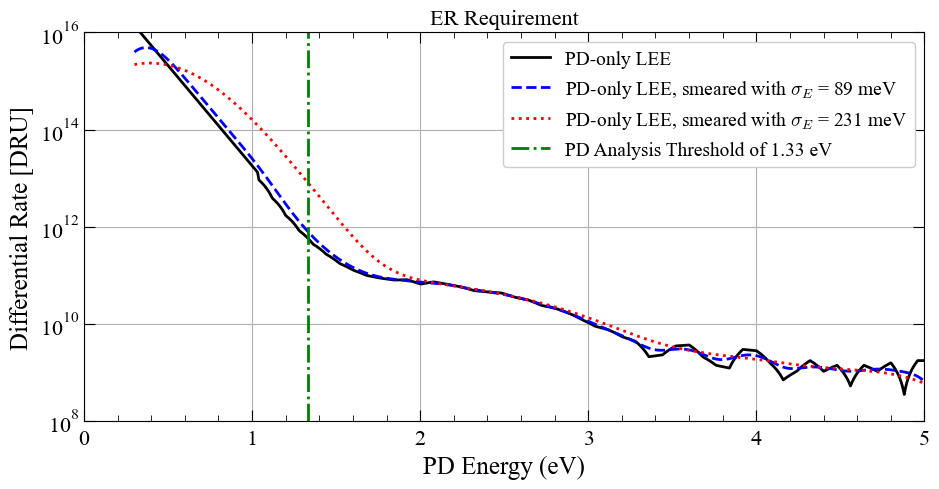

In [5]:
lee_input_file = 'Run57_LEE_templates/combined_spectra_shared57_CRESST_extrap.txt'
lee_scale = 1. # From volume scaling

def run57_lee_bkgd():
    template = np.loadtxt(lee_input_file, skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400. * lee_scale)

E_arr_PD = np.linspace(0.3e-3, 5e-3, 20_000)
PD_volume_scale = 49 * 0.3 / 100
PD_volume_cm3 = PD_volume_scale / 10
PD_mass_kg = PD_volume_cm3 * 2.33e-3

dRdE_arr_LEE = run57_lee_bkgd()(E_arr_PD) # Units of Hz/keV
dRdE_arr_PD = run57_lee_bkgd()(E_arr_PD) * PD_volume_scale / PD_mass_kg * 86400. # Units of DRU
dRdE_arr_PD /= 1. # Improvement factor

E_res_PD = 0.089e-3
E_th_PD = 1.33e-3

dRdE_arr_PD_smeared_89meV = darklim.limit.gauss_smear(E_arr_PD, dRdE_arr_PD, 0.089e-3)
dRdE_arr_PD_smeared_231meV = darklim.limit.gauss_smear(E_arr_PD, dRdE_arr_PD, 0.231e-3)

fig, ax = plt.subplots(1, 1, figsize=(9.5, 5))
ax.plot(E_arr_PD * 1e3, dRdE_arr_PD, 'k-', lw=2, label=f'PD-only LEE')
ax.plot(E_arr_PD * 1e3, dRdE_arr_PD_smeared_89meV, 'b--', lw=2, label=f'PD-only LEE, smeared with $\sigma_E$ = 89 meV')
ax.plot(E_arr_PD * 1e3, dRdE_arr_PD_smeared_231meV, 'r:', lw=2, label=f'PD-only LEE, smeared with $\sigma_E$ = 231 meV')
ax.plot([1.33, 1.33], [1e8, 1e16], 'g-.', lw=2, label='PD Analysis Threshold of 1.33 eV')

R_base = np.trapz(dRdE_arr_PD[E_arr_PD >= E_th_PD], E_arr_PD[E_arr_PD >= E_th_PD])
R_smeared_89meV = np.trapz(dRdE_arr_PD_smeared_89meV[E_arr_PD >= E_th_PD], E_arr_PD[E_arr_PD >= E_th_PD])
R_smeared_231meV = np.trapz(dRdE_arr_PD_smeared_231meV[E_arr_PD >= E_th_PD], E_arr_PD[E_arr_PD >= E_th_PD])

#ax.plot(4.9, 1e13, 'ro', label=f'PD-only LEE, smeared with $\sigma_E$ = 231 meV')

print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD: {R_base:.2e} cts/kg/day')
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD, smeared with $\sigma_E$ = 89 meV: {R_smeared_89meV:.2e} cts/kg/day')
print(f'LEE rate above {E_th_PD*1e3:.3f} eV in PD, smeared with $\sigma_E$ = 231 meV: {R_smeared_231meV:.2e} cts/kg/day')

ax.set_yscale('log')
ax.set_xlim([0, 5])
ax.set_ylim([1e8, 1e16])
ax.set_xlabel('PD Energy (eV)')
ax.set_ylabel('Differential Rate [DRU]')
ax.set_title('ER Requirement', fontsize=16)
ax.legend(loc='upper right', fontsize=14, framealpha=1)
ax.grid('on')
fig.tight_layout()
fig.show()




Confirming we are in the right directory
 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://

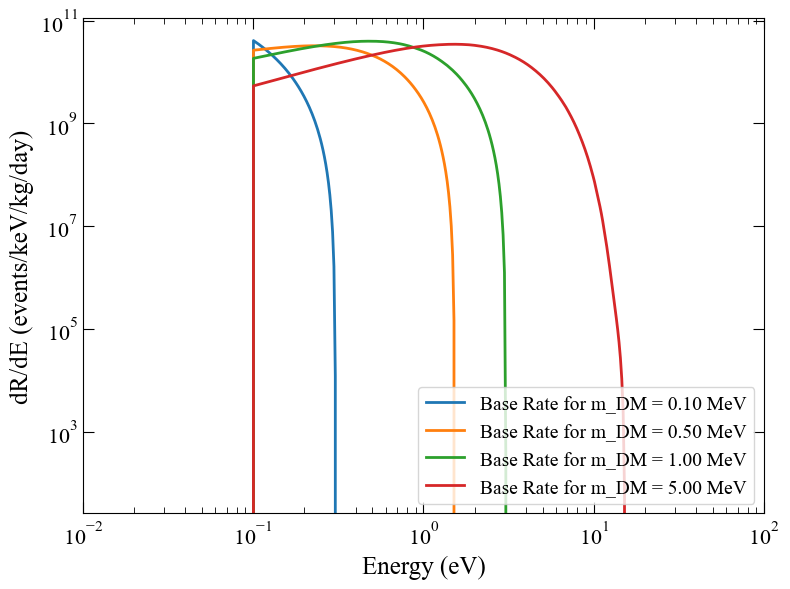

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))


for mX_eV in [0.1e6, 0.5e6, 1e6, 5e6]:  # 1 MeV, 5 MeV, 10 MeV

    E_keV_arr = np.geomspace(1e-6, 100, 1000)
    
    si = darkelf.darkelf(target='Si', filename="Si_mermin.dat")
    si.update_params(mX=mX_eV, mediator='massless')

    elf_fun = lambda keV : si.dRdomega_electron(keV * 1000, sigmae=1e-31) * (1000 / 365.25) 
    dRdE_arr = np.array([elf_fun(E) for E in E_keV_arr])

    ax.plot(E_keV_arr * 1e3, dRdE_arr, label=f'Base Rate for m_DM = {mX_eV/1e6:.2f} MeV')
    
ax.set_xscale('log')
ax.set_xlim([1e-2, 1e2])
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='lower right', fontsize=14)
fig.tight_layout()
fig.show()

TypeError: SensEst.run_sim() got an unexpected keyword argument 'force_e_max'

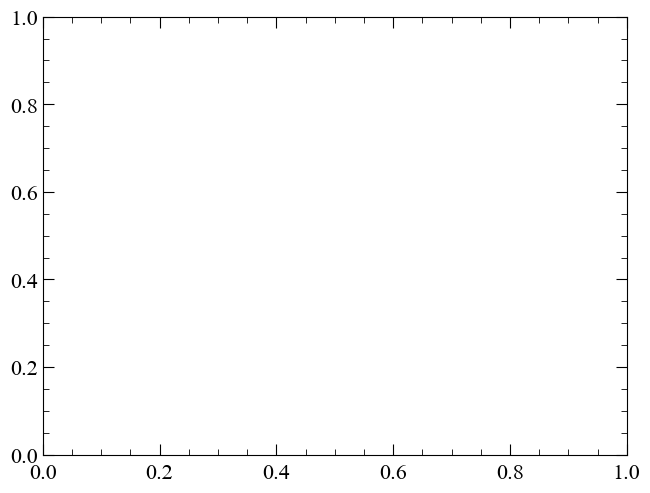

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

drde_function = SE.run_sim(threshold_keV, e_high=50e-3, e_low=1e-3, m_dms=[10], nexp=1, npts=100_000,
            plot_bkgd=False, res=None, verbose=False, sigma0=1e-37,
            elf_model=None, elf_params={}, elf_target=None,
            gaas_params=gaas_params, return_only_drde=True, force_e_max=None)[0]

E_keV_arr = np.geomspace(1e-6, 100, 1000)
dRdE_obs_arr = drde_function(E_keV_arr)

ax.plot(E_keV_arr, dRdE_obs_arr, label='10 GeV Observed dR/dE in GaAs', color='blue')

drde_function = SE.run_sim(threshold_keV, e_high=50e-3, e_low=1e-3, m_dms=[1.], nexp=1, npts=100_000,
            plot_bkgd=False, res=None, verbose=False, sigma0=1e-37,
            elf_model=None, elf_params={}, elf_target=None,
            gaas_params=gaas_params, return_only_drde=True, force_e_max=None)[0]

E_keV_arr = np.geomspace(1e-6, 100, 1000)
dRdE_obs_arr = drde_function(E_keV_arr)

ax.plot(E_keV_arr, dRdE_obs_arr, label='1 GeV Observed dR/dE in GaAs', color='red')

E_bkgd_arr, dRdE_bkgd_arr = np.loadtxt('required_performance_NR_like/background_spectrum_3fold.txt', unpack=True)
ax.plot(E_bkgd_arr, dRdE_bkgd_arr / mass_kg, label='Background dR/dE', color='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy (keV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='upper left', fontsize=12)
fig.tight_layout()
fig.show()

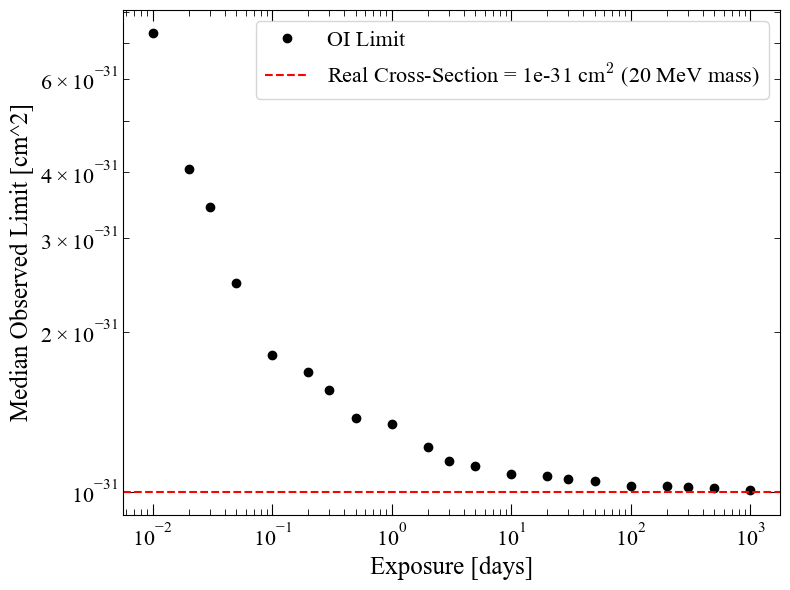

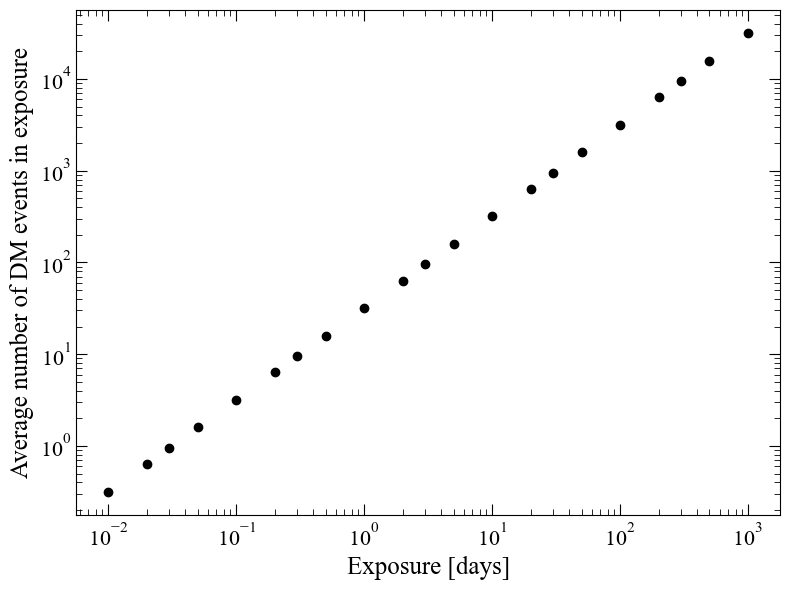

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

t_days_arr = ['0p01', '0p02', '0p03', '0p05', '0p1', '0p2', '0p3', '0p5', '1', '2', '3', '5', '10', '20', '30', '50', '100', '200', '300', '500', '1000']
t_float_arr  = [float(t_days.replace('p', '.')) for t_days in t_days_arr]
N_events = np.zeros_like(t_float_arr)

mass_kg = 0.009375 * 3.98 * 1e-3
E_th_keV = 64e-6 * 5
sigma0 = 1e-31

for i, t_days in enumerate(t_days_arr):
    
    try:
        t_float = t_float_arr[i]
        m_lim, x_lim = np.loadtxt(f'save_single_mass_20_MeV_bugfix/single_mass_{t_days}_days/limit.txt', unpack=True)
        ax.plot(t_float, x_lim, 'ko', ms=6, label='OI Limit'*(i==0))
        
        E_arr = np.geomspace(E_th_keV, 100, 1000)
        dRdE_arr = darklim.limit.drde(E_arr, m_lim, sigma0, 'Al2O3') * mass_kg * t_float
        N_events[i] = np.trapz(dRdE_arr, E_arr)
        
        # x_lim_poisson = darklim.feldman_cousins.FC_ints(int(N_events[i]), 0.)[1] / N_events[i] * sigma0
        # ax.plot(t_float, x_lim_poisson, 'bo', markersize=6, markerfacecolor='none', markeredgewidth=2, label='Poisson Limit from Average No. of Events'*(i==0))
        
    except FileNotFoundError:
        print(f"Limit file for {t_days} days not found. Skipping...")
        continue
    
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_ylim([0, 4e-35])

xmin, xmax = ax.get_xlim()
ax.plot([xmin, xmax], [sigma0, sigma0], 'r--', lw=1.5, label=f'Real Cross-Section = {sigma0} cm$^2$ (20 MeV mass)')
ax.set_xlim([xmin, xmax])

ax.set_xlabel('Exposure [days]')
ax.set_ylabel('Median Observed Limit [cm^2]')
ax.legend(loc='upper right', fontsize=16)

fig.tight_layout()
fig.show()

################

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(t_float_arr, N_events, 'ko', ms=6)
    
ax.set_xscale('log')
ax.set_xlim([xmin, xmax])
ax.set_yscale('log')

ax.set_xlabel('Exposure [days]')
ax.set_ylabel('Average number of DM events in exposure')

fig.tight_layout()
fig.show()


Limit file for 2000 eV not found. Skipping...
Limit file for 3000 eV not found. Skipping...
Limit file for 5000 eV not found. Skipping...
Limit file for 10000 eV not found. Skipping...
Limit file for 20000 eV not found. Skipping...
Limit file for 30000 eV not found. Skipping...
Limit file for 50000 eV not found. Skipping...
Limit file for 100000 eV not found. Skipping...
3.1737541987818565
2.3379252252263043e-31


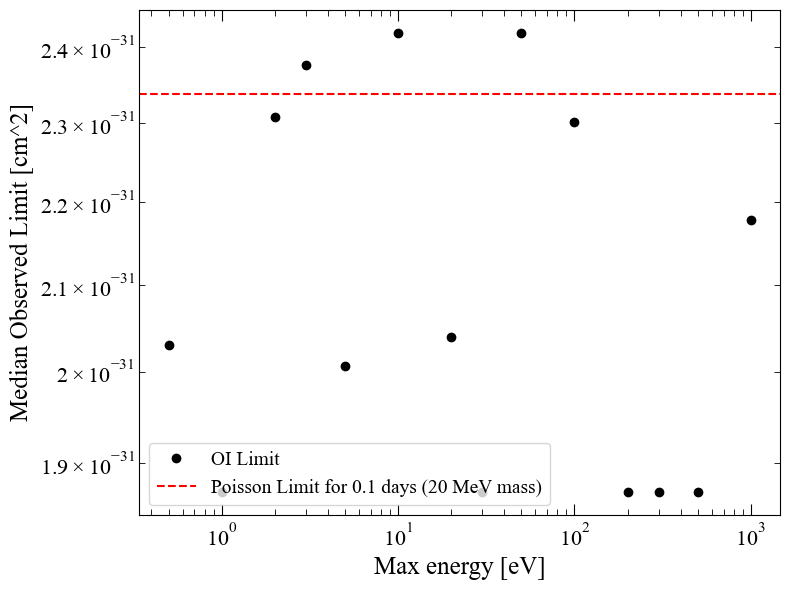

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

e_high_arr = ['0p5', '1', '2', '3', '5', '10', '20', '30', '50', '100', '200', '300', '500', '1000', '2000', '3000', '5000', '10000', '20000', '30000', '50000', '100000']
e_float_arr  = [float(e_high.replace('p', '.')) for e_high in e_high_arr]
N_events = np.zeros_like(e_float_arr)

mass_kg = 0.009375 * 3.98 * 1e-3
E_th_keV = 64e-6 * 5
sigma0 = 1e-31
t_float = 0.1

for i, e_high in enumerate(e_high_arr):
    
    try:
        e_float = e_float_arr[i]
        m_lim, x_lim = np.loadtxt(f'single_mass_e_high_{e_high}eV/limit.txt', unpack=True)
        ax.plot(e_float, x_lim, 'ko', ms=6, label='OI Limit'*(i==0))
                
    except FileNotFoundError:
        print(f"Limit file for {e_high} eV not found. Skipping...")
        continue
    
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_ylim([0, 4e-35])

# Poisson Limit Calculation
E_arr = np.geomspace(E_th_keV, 100, 1000)
dRdE_arr = darklim.limit.drde(E_arr, m_lim, sigma0, 'Al2O3') * mass_kg * t_float
N_events = np.trapz(dRdE_arr, E_arr)
print(N_events)
x_lim_poisson = darklim.feldman_cousins.FC_ints(int(N_events), 0.)[1] / N_events * sigma0

xmin, xmax = ax.get_xlim()
ax.plot([xmin, xmax], [x_lim_poisson, x_lim_poisson], 'r--', lw=1.5, label=f'Poisson Limit for {t_float} days (20 MeV mass)')
ax.set_xlim([xmin, xmax])
print(x_lim_poisson)

ax.set_xlabel('Max energy [eV]')
ax.set_ylabel('Median Observed Limit [cm^2]')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
fig.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


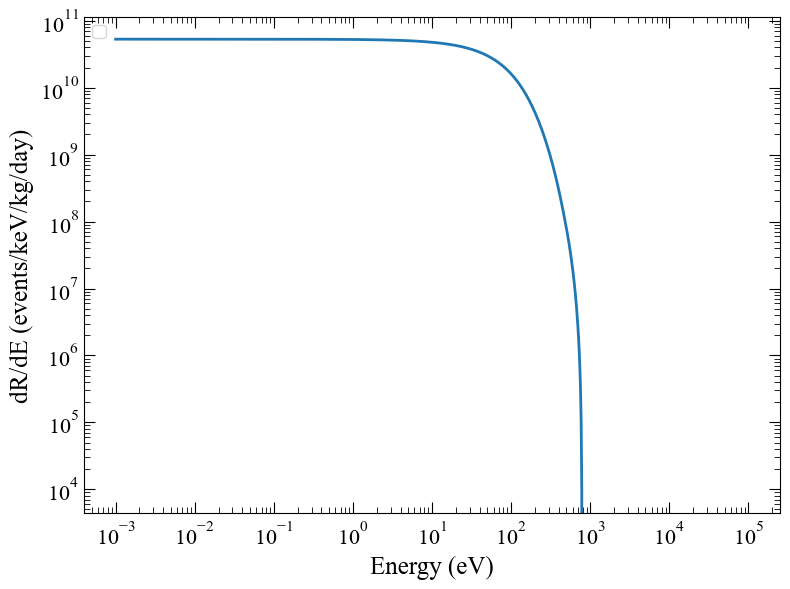

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

E_keV_arr = np.geomspace(1e-6, 100, 1000)
dRdE_obs_arr = darklim.limit.drde(E_keV_arr, 1, 1e-31, 'Al2O3')

ax.plot(E_keV_arr*1e3, dRdE_obs_arr)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('dR/dE (events/keV/kg/day)')
ax.legend(loc='upper left', fontsize=12)
fig.tight_layout()
fig.show()

In [ ]:
import scanparser

# Read command-line arguments
args = scanparser.get_scan_parameters()

# Force some parameters
args.target = 'Al2O3'
args.t_days = 0.1
args.masses_GeV = [0.020]
args.nexp = 50
mass = args.masses_GeV[0]
args.sigma0 = 1e-31

SE = darklim.sensitivity.SensEst(args.target_mass_kg, args.t_days, tm=args.target, eff=1., gain=1., seed=(int(time.time() + mass*1e6)))
SE.reset_sim()
SE.add_dm_bkgd(mass, args.sigma0)

per_device_threshold_keV = args.nsigma * args.baseline_res_eV * 1e-3
threshold_keV = args.coincidence * per_device_threshold_keV

_, sigs_all, sigs_fc, sig, sig_fc = SE.run_sim(
        threshold_keV,
        e_high=args.e_high_keV,
        #e_low=1e-6,
        m_dms=[mass],
        nexp=args.nexp,
        npts=100_000,
        plot_bkgd=False,
#            res=args.baseline_res_eV*1e-3,
        res=None,
        verbose=True,
        sigma0=args.sigma0,
        elf_model=args.elf_model,
        elf_target=args.target,
        elf_params=args.elf_params,
        return_only_drde=False,
        return_fc=True
#            gaas_params=None
)


In the first pseudoexperiment for mass 0.02 GeV, we simulated 18 events
On mass 1 of 1. E_high is 0.430 eV, E_low is 0.320 eV.
Total integrated rate for mass 0.02 GeV: 1.574e+01 events.
Optimum interval for mass 0.02 GeV: [0.320, 0.329] eV
Endpoints: 0, 6. UL output: 24.297 events
Cross section upper limit for mass 0.02 GeV: 1.543e-31 cm^2


[[1.54326695e-31 1.75821044e-31 2.32651169e-31 1.08507657e-31
  1.77462909e-31 1.51852570e-31 1.05757941e-31 1.75093421e-31
  1.35941161e-31 7.97092475e-32 1.31319857e-31 1.66260116e-31
  1.91526681e-31 1.66845825e-31 1.49257187e-31 1.06939039e-31
  1.00004902e-31 1.53795055e-31 9.90508930e-32 1.47887932e-31
  1.70590746e-31 1.13595434e-31 1.42657756e-31 9.45128912e-32
  1.71322925e-31 1.00624975e-31 9.64872810e-32 1.72142828e-31
  1.14633551e-31 1.56116956e-31 1.24235573e-31 1.52794095e-31
  1.24221351e-31 1.38484062e-31 9.16118237e-32 9.93444500e-32
  1.72790831e-31 1.05042372e-31 1.45616599e-31 1.49251299e-31
  2.04053129e-31 1.41416023e-31 1.38285123e-31 1.74146057e-31
  1.35459422e-31 1.47161460e-31 1.04319232e-31 1.68914366e-31
  1.23949588e-31 1.22315186e-31]]
[[1.34485340e-31 1.34485340e-31 1.28824096e-31 1.43639109e-31
  1.34485340e-31 1.35157880e-31 1.47110555e-31 1.35157880e-31
  1.38622644e-31 1.43639109e-31 1.43639109e-31 1.36434028e-31
  1.30519746e-31 1.34485340e-31 1.38

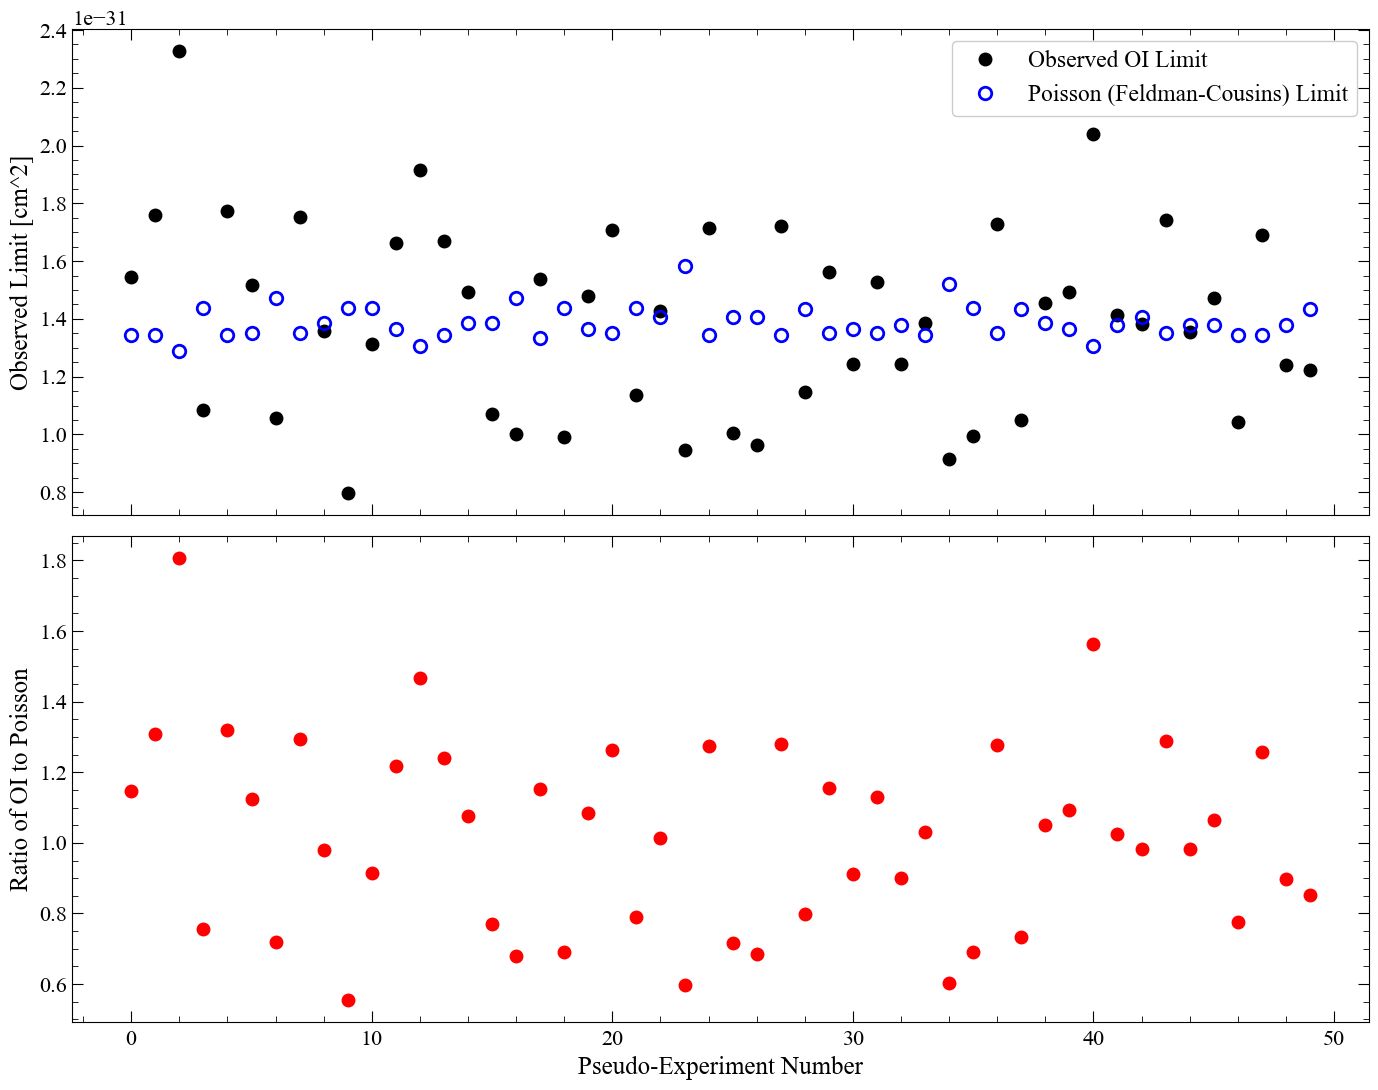

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

nexp = len(sigs_all[0])
ax[0].plot(np.arange(nexp), sigs_all[0], 'ko', ms=9, label='Observed OI Limit')
ax[0].plot(np.arange(nexp), sigs_fc[0], 'bo', markersize=9, markerfacecolor='none', markeredgewidth=2, label='Poisson (Feldman-Cousins) Limit')

ax[0].legend(loc='best', fontsize=17, framealpha=1)
ax[0].set_ylabel('Observed Limit [cm^2]')

ax[1].plot(np.arange(nexp), sigs_all[0] / sigs_fc[0], 'ro', ms=9)

ax[1].set_xlabel('Pseudo-Experiment Number')
ax[1].set_ylabel('Ratio of OI to Poisson')

fig.tight_layout()
fig.show()

print(sigs_all)
print(sigs_fc)

In [52]:
import scanparser
from darklim.feldman_cousins import FC_ints

# Read command-line arguments
args = scanparser.get_scan_parameters()

# Force some parameters
args.target = 'Al2O3'
args.t_days = 0.1
args.masses_GeV = [0.020]
args.nexp = 50
mass = args.masses_GeV[0]

SE = darklim.sensitivity.SensEst(args.target_mass_kg, args.t_days, tm=args.target, eff=1., gain=1., seed=(int(time.time() + mass*1e6)))
SE.reset_sim()
SE.add_dm_bkgd(mass, args.sigma0)

per_device_threshold_keV = args.nsigma * args.baseline_res_eV * 1e-3
threshold_keV = args.coincidence * per_device_threshold_keV
e_high_keV = 0.5e-3

E_interp = np.geomspace(threshold_keV, e_high_keV, 10_000)
evts_sim = SE._generate_background(E_interp)
evts_sim = np.array(sorted(evts_sim))

print('Simulated event energies (eV):', evts_sim*1e3)

rate_interp = darklim.limit.drde(E_interp, mass, args.sigma0, args.target) * args.target_mass_kg * args.t_days
N_average = np.trapz(rate_interp, E_interp)
pdf_interp = rate_interp / N_average
cdf_interp = np.cumsum(pdf_interp) / np.sum(pdf_interp)
print('Average number of events:', N_average)

evts_fc = np.zeros_like(evts_sim)
for i, evt in enumerate(evts_sim):
    evts_fc[i] = np.interp(evt, E_interp, cdf_interp)
print('CDF values:', evts_fc)
if len(evts_fc) == 0:
    evts_fc = np.array([0., 1.])

uloutput, endpoint0, endpoint1 = darklim.limit.upper(evts_fc, 0.9)
sigma_oi = (args.sigma0 / N_average) * uloutput

oi_energy0 = evts_sim[endpoint0-1] if endpoint0>0 else threshold_keV # endpoint==0 means the start of the SM integration range
oi_energy1 = evts_sim[endpoint1-1] if (len(evts_sim) > 0 and endpoint1-1 < len(evts_fc)) else e_high_keV

print(f"Optimum interval for mass {mass} GeV: [{oi_energy0*1e3:.3f}, {oi_energy1*1e3:.3f}] eV")
print(f"Endpoints: {endpoint0}, {endpoint1}. UL output: {uloutput:.3f} events")
print(f"Cross section upper limit for mass {mass} GeV: {sigma_oi:.3e} cm^2")

print('')
print('Feldman-Cousins (90%):', FC_ints(len(evts_sim), 0., 0.1))
if  FC_ints(len(evts_sim), 0., 0.1)[0] > 0:
    print('Feldman-Cousins (80%):', FC_ints(len(evts_sim), 0., 0.2))




Simulated event energies (eV): [0.32008723 0.32359905 0.32518847 0.32581248]
Average number of events: 3.148755144640545
CDF values: [0.00884601 0.28081792 0.38382681 0.42114697]
Optimum interval for mass 0.02 GeV: [0.326, 0.500] eV
Endpoints: 4, 5. UL output: 7.281 events
Cross section upper limit for mass 0.02 GeV: 2.312e-31 cm^2

Feldman-Cousins (90%): (1.475, 8.595)
Feldman-Cousins (80%): (1.4747477988156796, 7.644747798815685)


# Varying Exposure Time

In [2]:
def extrapolate(data, mass=1e6):
    m0, s0 = data[-1]
    return np.concatenate([data,[[mass, s0*mass/m0]]], axis=0)

def minbound(curves, masses=None):
    if masses is None:
        masses = np.logspace(-3, 4, 200)
    result = np.array([np.nan]*len(masses))
    for curve in curves:
        if curve[-1][0] < masses[-1]:
            curve = extrapolate(curve, masses[-1])
        yinterp = 10**(interp1d(*(np.log10(curve).T), bounds_error=False)(np.log10(masses)))
        #yinterp = interp1d(*(curve.T), bounds_error=False)(masses)
        result = np.nanmin([result, yinterp], axis=0)
    return np.array([masses, result]).T

def log_interp(zz, xx, yy, left=None, right=None):
    logz = np.log(zz)
    logx = np.log(xx)
    logy = np.log(yy)
    return np.exp(np.interp(logz, logx, logy, left=left, right=right))

def load_and_plot_existing(leg=True, lw=1, leg_params={}, ER_model='massless', cosmic=False, migdal=False, direct=False):
    
    curves_dir = 'ExistingLimits/'
    handles = []
    fig, ax = plt.subplots(1, 1, figsize=(10,7.5))
    ax.set_xscale('log')
    ax.set_yscale('log')
    mpl.rcParams['font.size'] = 14
    
    if ER_model == 'massive':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massive_2025.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massive_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CE977A', lw=lw, label='Darkside-50 2023')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_ER_Massive_2023.txt').transpose()
        l, = ax.plot(m_lim*1e3, x_lim, '--', color='#CA778C', lw=lw, label='PandaX-4T 2023')
        handles.append(l)
        ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='whitesmoke')
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_out_Scalar_ER_Massive.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='orange', lw=lw*2, label='Freeze-out Scalar')
        handles.append(l)

        #m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_S2Only_Solar_Reflected_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='XENON1T S2only (Solar Refl.)')
        #m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_Solar_Reflection_ER_Massive.txt').transpose()
        #ax.plot(m_lim, x_lim, '--', lw=1.5, label='SENSEI SNOLAB (Solar Refl.)')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'massless':
        
        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_ER_Massless_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim_1, x_lim_1 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2023.txt').transpose()
        m_lim_2, x_lim_2 = np.loadtxt(curves_dir + 'DAMIC_ER_Massless_2024.txt').transpose()
        m_lim = np.geomspace(min(m_lim_1[0], m_lim_2[0]), max(m_lim_1[-1], m_lim_2[-1]), 150)
        x_lim_1_adj = log_interp(m_lim, m_lim_1, x_lim_1, left=np.inf, right=np.inf)
        x_lim_2_adj = log_interp(m_lim, m_lim_2, x_lim_2, left=np.inf, right=np.inf)
        x_lim = np.minimum(x_lim_1_adj, x_lim_2_adj)
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='DAMIC 2023, 2024')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_SNOLAB_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e-22, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'Freeze_in_ER_Massless.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='Freeze-in')
        handles.append(l)

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    elif ER_model == 'absorption':

        m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='magenta', lw=lw, label='LBC (DAMIC) 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Absorption_2025.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CFC0E5', lw=lw, label='SENSEI 2025')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Absorption_2019.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#a4dbed', lw=lw, label='XENON1T 2019')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2022.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '-', color='#FF9039', lw=lw*2, label='XENONnT 2022')
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Lower.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw, label='XENONnT 2024')
        handles.append(l)

        m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_Absorption_2024_Upper.txt').transpose()
        l, = ax.plot(m_lim, x_lim, '--', color='#CA778C', lw=lw)
        handles.append(l)
        ax.fill_between(m_lim, x_lim, 1e0, facecolor='whitesmoke')

        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)

    else:

        if cosmic:

            m_lim = ML.Data_Cosmic_ray[:,0]
            x_lim = ML.Data_Cosmic_ray[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-.', label="Cosmic ray scattered DM")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')

            m_lim = ML.Data_Milky_way_satellites_2021[:,0]
            x_lim = ML.Data_Milky_way_satellites_2021[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='--', label="Milky Way satellites")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')

            m_lim = ML.Data_Ly_alpha_2022[:,0]
            x_lim = ML.Data_Ly_alpha_2022[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle=':', label="Ly-alpha forest")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')
            
            m_lim = ML.Data_CMB[:,0]
            x_lim = ML.Data_CMB[:,1]
            ax.plot(m_lim, x_lim, linewidth=0.5, color='gray', linestyle='-', label="CMB")
            ax.fill_between(m_lim, np.ones_like(x_lim)*1e-22, x_lim, color='whitesmoke')
            
        if migdal:
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'DAMIC_LBC_Migdal_2025.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CFC0E5', linestyle='--', label='LBC (DAMIC) Migdal 2025')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'SENSEI_Migdal_NR.txt').transpose()
            l, = ax.plot(m_lim, x_lim, lw=lw, color='#CE977A', linestyle='--', label='SENSEI Migdal NR')
            handles.append(l)
            ax.fill_between(m_lim, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'Darkside50_Migdal_2023.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#a4dbed', linestyle='--', label='Darkside-50 Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_Migdal_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CA778C', linestyle='--', label='PandaX4T Migdal 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)
            
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENON1T_Migdal_2019.txt').transpose()
            l, ax.plot(m_lim*1e3, x_lim, lw=lw, color='#FF9039', linestyle='--', label='XENON1T Migdal 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-22, facecolor='#ad8150', alpha=0.1)

            ### SuperCDMS Migdal 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'SuperCDMS_Migdal_2023_Overburden.txt').transpose()
            
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0]), max(m_lim[-1], m_lim_overburden[-1]), 150 )
            l, = ax.plot(m_range*1e3, log_interp(m_range, m_lim, x_lim), lw=lw, color='magenta', linestyle='--', label='SuperCDMS Migdal 2023')
            handles.append(l)
            ax.plot(m_range*1e3, log_interp(m_range, m_lim_overburden, x_lim_overburden), lw=lw, color='magenta', linestyle='--')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='magenta', linestyle='--')
            ax.fill_between(m_range*1e3,
                            log_interp(m_range, m_lim, x_lim),
                            log_interp(m_range, m_lim_overburden, x_lim_overburden),
                            facecolor='#ad8150', alpha=0.1)
            
        if direct:
        
            ### SuperCDMS CPD ###
            m_lim, x_lim = ML.cpdlimit_down[:,0], ML.cpdlimit_down[:,1]
            m_lim_overburden, x_lim_overburden = ML.cpdlimit_up[:,0], ML.cpdlimit_up[:,1]
            l, = ax.plot(m_lim*1e3, x_lim, lw=lw, color='#CE977A', linestyle='-', label='SuperCDMS CPD')
            handles.append(l)
            ax.plot(m_lim_overburden*1e3, x_lim_overburden, lw=lw, color='#CE977A', linestyle='-')
            ax.plot([m_lim[0]*1e3, m_lim[0]*1e3], [x_lim[0], x_lim_overburden[0]], lw=lw, color='#CE977A', linestyle='-')
            ax.fill_between(m_lim*1e3, x_lim, x_lim_overburden, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2019 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2019.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='#a4dbed', lw=lw, label='CRESST-III 2019')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)

            ### CRESST-III 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'CRESST_III_2024_Extended.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'CRESST_III_2024_Overburden.txt').transpose()

            # Find point of intersection between limit and overburden
            m_range = np.geomspace( max(m_lim[0], m_lim_overburden[0]), min(m_lim[-1], m_lim_overburden[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_overburden, x_lim_overburden, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )

            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw, label='CRESST-III 2024')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.), linestyle='-', color='#CFC0E5', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_overburden*1e3, x_lim_overburden, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### TESSERACT 2025 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'TESSERACT_2025_Limit.txt').transpose()
            m_lim_overburden, x_lim_overburden = np.loadtxt(curves_dir + 'TESSERACT_2025_Overburden.txt').transpose()
            m_lim_pileup, x_lim_pileup = np.loadtxt(curves_dir + 'TESSERACT_2025_Pileup.txt').transpose()
            
            # Find point of intersection between limit and pileup
            m_range = np.geomspace( min(m_lim[0], m_lim_overburden[0], m_lim_pileup[0]), min(m_lim[-1], m_lim_overburden[-1], m_lim_pileup[-1]), 150 )
            idx_intersect = np.argmin(
                np.abs(
                    np.log(np.interp(m_range, m_lim_pileup, x_lim_pileup, left=0., right=0.)) - 
                        np.log(np.interp(m_range, m_lim, x_lim, left=0., right=0.))
                )
            )
            
            # Plot excluded region
            m_plot = m_range[idx_intersect:]
            l, = ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw, label='TESSERACT 2025')
            handles.append(l)
            ax.plot(m_plot*1e3, log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.), linestyle='-', color='#CA778C', lw=lw)
            ax.fill_between(m_plot*1e3,
                            log_interp(m_plot*1e3, m_lim*1e3, x_lim, left=0., right=0.),
                            log_interp(m_plot*1e3, m_lim_pileup*1e3, x_lim_pileup, left=0., right=0.),
                            facecolor='#dbdbdb', alpha=0.75)

            ### LZ 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'LZ_SI_2024.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='pink', lw=lw, label='LZ 2024')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)

            ### XENONnT 2024 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'XENONnT_SI_2024.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='green', lw=lw, label='XENONnT 2024')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)
            
            ### PandaX4T 2023 ###
            m_lim, x_lim = np.loadtxt(curves_dir + 'PandaX4T_S2_Only_2023.txt').transpose()
            l, = ax.plot(m_lim*1e3, x_lim, '-', color='orange', lw=lw, label='PandaX4T 2023')
            handles.append(l)
            ax.fill_between(m_lim*1e3, x_lim, 1e-10, facecolor='#dbdbdb', alpha=0.75)
            
        if leg:
            leg1 = ax.legend(handles=handles, **leg_params)
            ax.add_artist(leg1)
            
    return fig, ax, handles

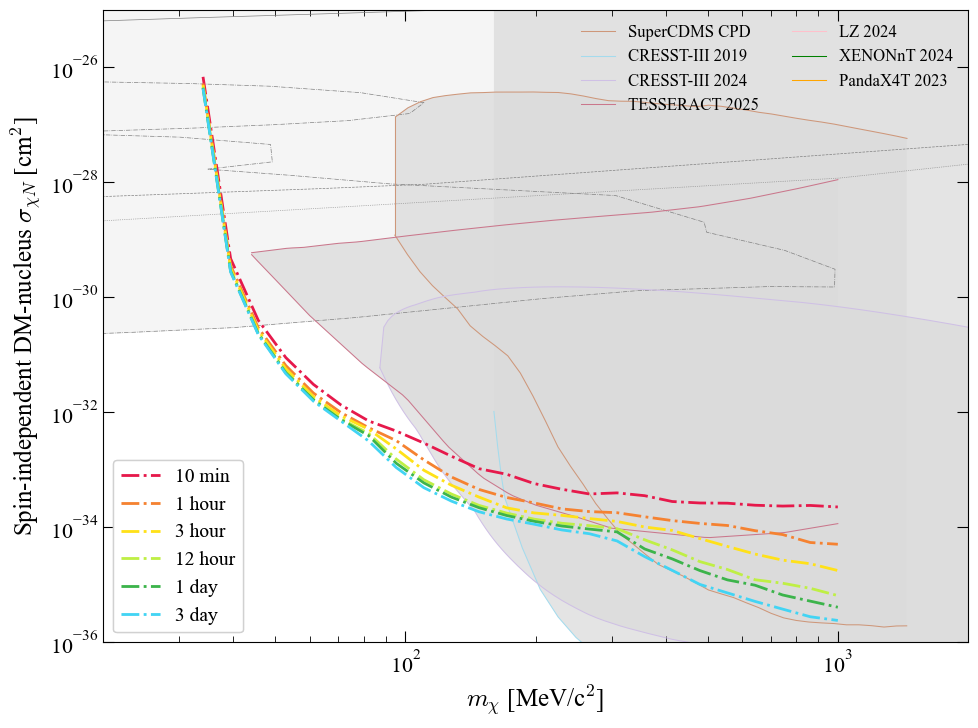

In [22]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []

colors = ['#E6194B', '#F58231', '#FFE119', '#BFEF45', '#3CB44B', '#42D4F4', '#4363D8', '#911EB4', '#F032E6', '#A9A9A9']
labels = ['10m', '1h', '3h', '12h', '1d', '3d']

for i, (label, color) in enumerate(zip(labels, colors)):
    
    label2 = label.replace('m', ' min').replace('h', ' hour').replace('d', ' day')
    
    m_lim, x_lim = np.loadtxt(f'darklim_debugging/varying_time/sapphire_vary_time_{label}/limit.txt', unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=color, linestyle='-.', label=label2)
    handles_calculated.append(l)

ax.set_xlim([2e1, 2e3])
ax.set_ylim([1e-36, 1e-25])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)

leg1 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=False, ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='lower left', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

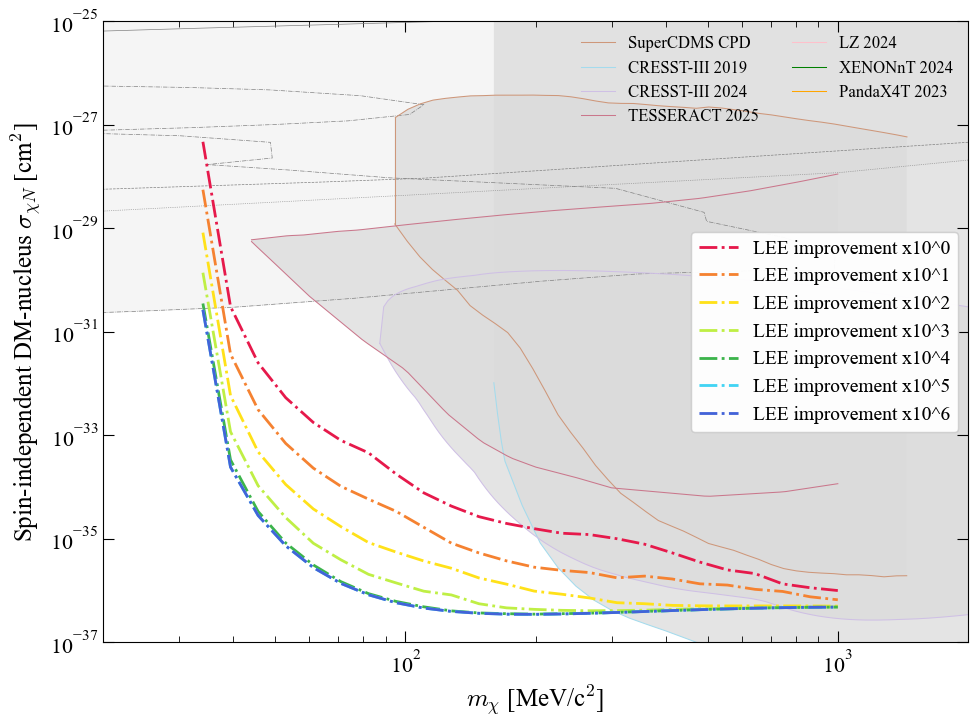

In [16]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []

colors = ['#E6194B', '#F58231', '#FFE119', '#BFEF45', '#3CB44B', '#42D4F4', '#4363D8', '#911EB4', '#F032E6', '#A9A9A9']
reductions = np.arange(7)

for i, (r, color) in enumerate(zip(reductions, colors)):
    m_lim, x_lim = np.loadtxt(f'darklim_debugging/varying_LEE/sapphire_vary_LEE_1e{r}/limit.txt', unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=color, linestyle='-.', label='LEE improvement x10^' + str(r))
    handles_calculated.append(l)

ax.set_xlim([2e1, 2e3])
ax.set_ylim([1e-37, 1e-25])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)

leg1 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=False, ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='center right', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

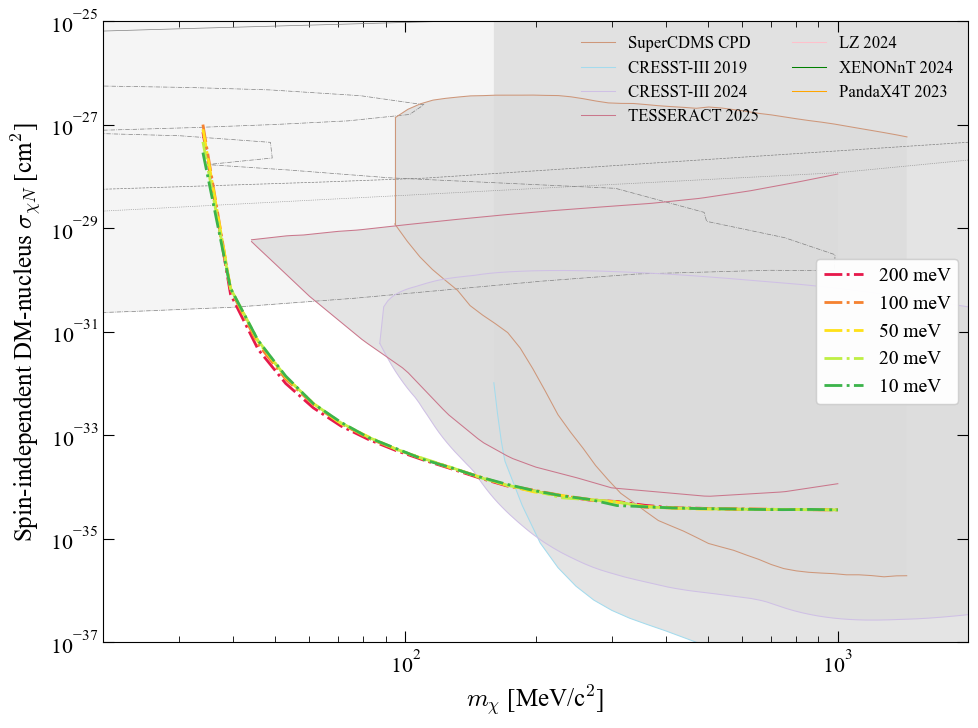

In [20]:
fig, ax, handles_existing = load_and_plot_existing(ER_model='None', lw=0.75, leg=False, cosmic=True, migdal=False, direct=True)
handles_calculated = []

colors = ['#E6194B', '#F58231', '#FFE119', '#BFEF45', '#3CB44B', '#42D4F4', '#4363D8', '#911EB4', '#F032E6', '#A9A9A9']
resolutions = [200, 100, 50, 20, 10]
for i, (res, color) in enumerate(zip(resolutions, colors)):
    m_lim, x_lim = np.loadtxt(f'darklim_debugging/varying_res/sapphire_vary_res_{res}meV/limit.txt', unpack=True)
    l, = ax.plot(m_lim*1e3, x_lim, lw=2, color=color, linestyle='-.', label=f'{res} meV')
    handles_calculated.append(l)

ax.set_xlim([2e1, 2e3])
ax.set_ylim([1e-37, 1e-25])
ax.set_xlabel(r'$m_\chi$ [MeV/c$^2$]', fontsize=18)
ax.set_ylabel(r'Spin-independent DM-nucleus $\sigma_{\chi N}$ [cm$^2$]', fontsize=18)

leg1 = ax.legend(handles=handles_existing, loc='upper right', fontsize=12, frameon=False, ncol=2)
ax.add_artist(leg1)

leg2 = ax.legend(handles=handles_calculated, loc='center right', fontsize=14, frameon=True, ncol=1)
ax.add_artist(leg2)

fig.tight_layout()
fig.show()

In [2]:
### Load template
template = detprocess.Template(verbose=True)
template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')

# Load shared 2x1 template to get the energy scale right, but we only use the left channel template shape and PSD
channel = 'Mv3025pcBigFinsLeft|Mv3025pcBigFinsRight'

templates_td, t_sec_template, metadata = template.get_template(channel, return_metadata=True, tag='shared')
templates_td = np.reshape(templates_td[0,0], (1,1,templates_td.shape[-1]))
_, _, f_frequencies = templates_td.shape
fs = metadata['sample_rate']
pretrig = metadata['nb_pretrigger_samples']

csd, freqs_csd, _ = template.get_csd(channel, fold=False, return_metadata=True, tag='default')
csd = np.reshape(csd[0,0], (1,1,csd.shape[-1]))

### Background parameters
rate_Hz = 100  # Event rate in Hz (for the simulation--this should be as high as possible without inducing pileup)

### Rescale template so that the energy resolution per channel is some assumed value
base_energy_resolution = 0.3977  # eV; this is the resolution of the 1x1 shared template from Run 57
desired_energy_resolution = 0.064
n_sigma = 5.0  # Number of sigma for the trigger

template_OF = np.copy(templates_td)
csd_OF = np.copy(csd) * (desired_energy_resolution / base_energy_resolution)**2


INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [25]:
trigger_times, trigger_amplitudes, true_arrival_times, sim_ids = \
    darklim.detector.DM_sim_OF(template_OF, csd_OF, fs, rate_Hz=rate_Hz, n_sigma=n_sigma, n_sims=100_000, mass_GeV=0.1, tm='Al2O3', seed=39391, n_cores=3)

trigger_amplitudes /= 1e3  # Convert to keV for plotting

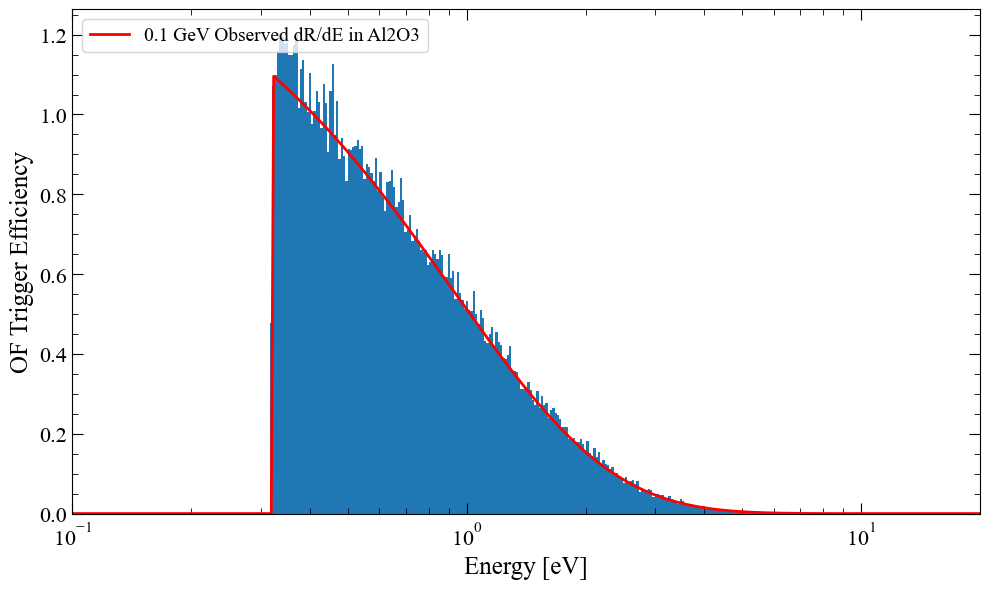

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

E_eV_arr = np.geomspace(1e-3, 1e3, 1_000)
dRdE_arr = darklim.limit.drde(E_eV_arr / 1e3, 0.1, 1e-37, 'Al2O3')
dRdE_arr = darklim.limit.gauss_smear(E_eV_arr / 1e3, dRdE_arr, desired_energy_resolution / 1e3)
dRdE_arr /= np.trapz(dRdE_arr, E_eV_arr / 1e3)
#dRdE_arr *= 0.5 * (erf((E_eV_arr - n_sigma * desired_energy_resolution) / np.sqrt(2) / desired_energy_resolution) + 1)
dRdE_arr *= np.heaviside(E_eV_arr - n_sigma * desired_energy_resolution, 0.5)

ax.plot(E_eV_arr, dRdE_arr/750, label='0.1 GeV Observed dR/dE in Al2O3', color='red')
ax.hist(trigger_amplitudes*1e3, np.geomspace(0.1, 20, 400), density=True)
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('OF Trigger Efficiency')
ax.set_xscale('log')
ax.set_xlim([0.1, 20])
#ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=14)

fig.tight_layout()
fig.show()

 .... Loading files for Al2O3
Loaded Al2O3_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from  F. Gervais and B. Piriou, Anharmonicity in several-polar-mode crystals:  adjusting phonon self-energy of LO and TO modes in Al2O3 and TiO2 to fit infrared reflectivity,Journal of Physics C Solid State Physics 7 (1974) 2374 and M. Schubert, T.E. Tiwald and C.M. Herzinger, Infrared dielectric anisotropy and phonon modes of sapphire, Phys. Rev. B61(2000) 8187
Loaded Al2O3_epsphonon_o.dat for epsilon in phonon regime
Warning, Al2O3_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation no

/home/vvelan/Test/DarkELF/darkelf/epsilon.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, delim_whitespace=True,header=None,skiprows=1,
/home/vvelan/Test/DarkELF/darkelf/epsilon.py:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(inplace=True,method='bfill')# fill in some NaN values


Loaded /home/vvelan/Test/DarkELF/data/Al2O3/Al2O3_pDoS_anisotropic.dat for partial densities of states
Al2O3_pDoS_anisotropic.dat
/home/vvelan/Test/DarkELF/data/Al2O3/Al2O3_Fn.npy
Warning! Al2O3_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 
 .... Loading files for Al2O3
Loaded Al2O3_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from  F. Gervais and B. Piriou, Anharmonicity in several-polar-mode crystals:  adjusting phonon self-energy of LO and TO modes in Al2O3 and TiO2 to fit infrared reflectivity,Journal of Physics C Solid State Physics 7 (1974) 2374 and M. Schubert, T.E. Tiwald and C.M. Herzinger, Infrared dielectric anisotropy and phonon modes of sapphire, Phys. Rev. B61(2000) 8187


/home/vvelan/Test/DarkELF/darkelf/epsilon.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, delim_whitespace=True,header=None,skiprows=1,
/home/vvelan/Test/DarkELF/darkelf/epsilon.py:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(inplace=True,method='bfill')# fill in some NaN values


Loaded /home/vvelan/Test/DarkELF/data/Al2O3/Al2O3_pDoS_anisotropic.dat for partial densities of states
Al2O3_pDoS_anisotropic.dat
/home/vvelan/Test/DarkELF/data/Al2O3/Al2O3_Fn.npy
Warning! Al2O3_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 


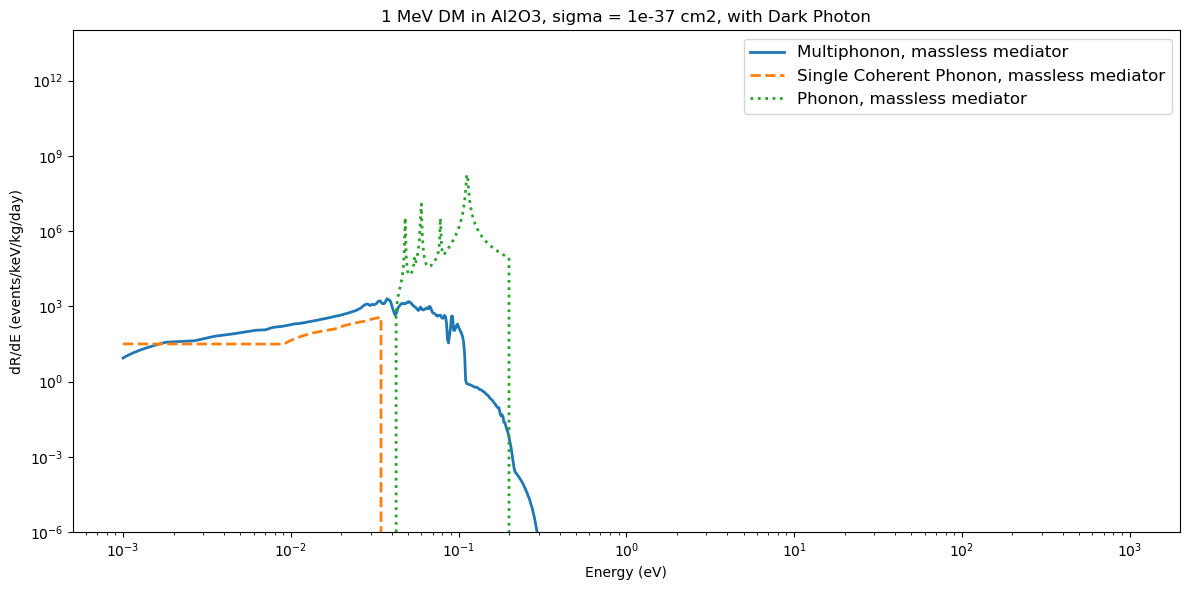

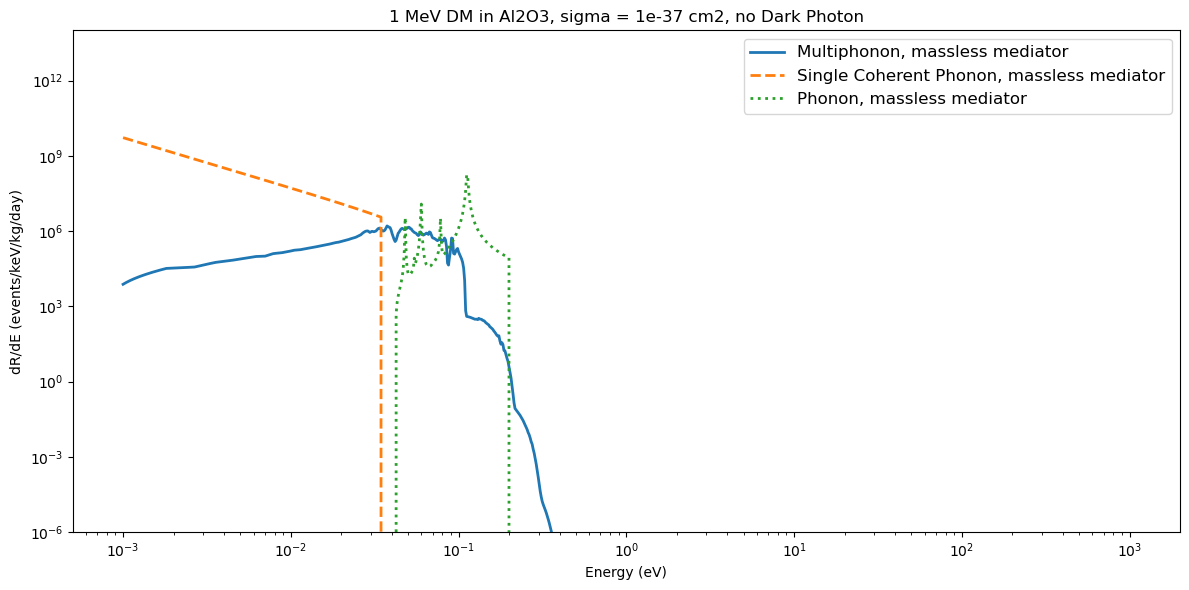

In [4]:
import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

# import darklim
#sys.path.insert(0, '/home/vvelan/DarkELF/')
sys.path.insert(0, '/home/vvelan/Test/DarkELF/')
from darkelf import darkelf

for dark_photon in [True, False]:

    fig, ax = plt.subplots(figsize=(12, 6))

    E_keV_arr = np.geomspace(1e-6, 1e0, 1000)
    E_eV_arr = E_keV_arr * 1e3
    # dRdE_arr_NR = darklim.limit.drde(E_eV_arr, 10e-3, 1e-37, 'Al2O3')

    # ax.plot(E_eV_arr, dRdE_arr_NR, 'k-', lw=2, label='Spin-Indep. NR')

    sapphire = darkelf(target='Al2O3', filename="Al2O3_mermin.dat", phonon_filename='Al2O3_epsphonon_o.dat', eps_data_dir='/home/vvelan/Test/DarkELF/data/')

    for mediator in ['massless']:
            
            sapphire.update_params(mX=1e6, mediator=mediator)
            dRdE_arr = [sapphire._dR_domega_multiphonons_SI(E, sigman=1e-37, dark_photon=dark_photon) for E in E_eV_arr]
            dRdE_arr = np.array(dRdE_arr) * 1000 / 365.25
            ax.plot(E_eV_arr, dRdE_arr, '-', lw=2, label=f'Multiphonon, {mediator} mediator')

            dRdE_arr = [sapphire._dR_domega_coherent_single(E, sigman=1e-37, dark_photon=dark_photon) for E in E_eV_arr]
            dRdE_arr = np.array(dRdE_arr) * 1000 / 365.25
            ax.plot(E_eV_arr, dRdE_arr, '--', lw=2, label=f'Single Coherent Phonon, {mediator} mediator')

            if mediator == 'massless':
                dRdE_arr = [sapphire.dRdomega_phonon(E, sigmae=1e-37) for E in E_eV_arr]
                dRdE_arr = np.array(dRdE_arr) * 1000 / 365.25
                ax.plot(E_eV_arr, dRdE_arr, ':', lw=2, label=f'Phonon, {mediator} mediator')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('dR/dE (events/keV/kg/day)')
    ax.set_ylim([1e-6, 1e14])
    ax.legend(loc='upper right', fontsize=12)
    if dark_photon:
        ax.set_title('1 MeV DM in Al2O3, sigma = 1e-37 cm2, with Dark Photon')
    else:
        ax.set_title('1 MeV DM in Al2O3, sigma = 1e-37 cm2, no Dark Photon')

    fig.tight_layout()
    fig.show()

 .... Loading files for Al2O3
Loaded Al2O3_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from  F. Gervais and B. Piriou, Anharmonicity in several-polar-mode crystals:  adjusting phonon self-energy of LO and TO modes in Al2O3 and TiO2 to fit infrared reflectivity,Journal of Physics C Solid State Physics 7 (1974) 2374 and M. Schubert, T.E. Tiwald and C.M. Herzinger, Infrared dielectric anisotropy and phonon modes of sapphire, Phys. Rev. B61(2000) 8187
Loaded Al2O3_epsphonon_o.dat for epsilon in phonon regime
Warning, Al2O3_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation no

/home/vvelan/Test/DarkELF/darkelf/epsilon.py:41: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, delim_whitespace=True,header=None,skiprows=1,
/home/vvelan/Test/DarkELF/darkelf/epsilon.py:44: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(inplace=True,method='bfill')# fill in some NaN values


Loaded /home/vvelan/Test/DarkELF/data/Al2O3/Al2O3_pDoS_anisotropic.dat for partial densities of states
Al2O3_pDoS_anisotropic.dat
/home/vvelan/Test/DarkELF/data/Al2O3/Al2O3_Fn.npy
Warning! Al2O3_Fn_anisotropic.npy does not exist! Need to calculate Fn(omega) from DoS. Use the function 'F_n_d_precompute' to produce these files 


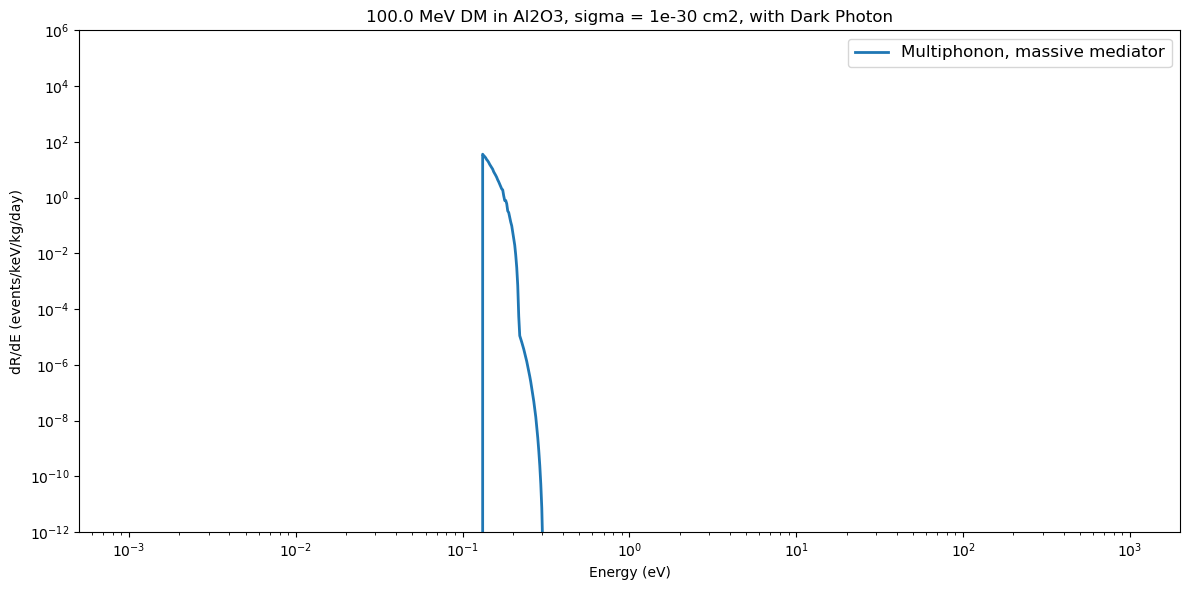

In [4]:
import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

# import darklim
#sys.path.insert(0, '/home/vvelan/DarkELF/')
sys.path.insert(0, '/home/vvelan/Test/DarkELF/')
from darkelf import darkelf


fig, ax = plt.subplots(figsize=(12, 6))

dark_photon = True

for mX in [100e3]:

    E_keV_arr = np.geomspace(1e-6, 1e0, 1000)
    E_eV_arr = E_keV_arr * 1e3
    # dRdE_arr_NR = darklim.limit.drde(E_eV_arr, 10e-3, 1e-37, 'Al2O3')

    # ax.plot(E_eV_arr, dRdE_arr_NR, 'k-', lw=2, label='Spin-Indep. NR')

    sapphire = darkelf(target='Al2O3', filename="Al2O3_mermin.dat", phonon_filename='Al2O3_epsphonon_o.dat', eps_data_dir='/home/vvelan/Test/DarkELF/data/')

    for mediator in ['massive']:
            
            sapphire.update_params(mX=mX, mediator=mediator)
            dRdE_arr = [sapphire._dR_domega_multiphonons_SI(E, sigman=1e-30, dark_photon=dark_photon) for E in E_eV_arr]
            dRdE_arr = np.array(dRdE_arr) * 1000 / 365.25
            ax.plot(E_eV_arr, dRdE_arr, '-', lw=2, label=f'Multiphonon, {mediator} mediator')

            # dRdE_arr = [sapphire._dR_domega_coherent_single(E, sigman=1e-37, dark_photon=dark_photon) for E in E_eV_arr]
            # dRdE_arr = np.array(dRdE_arr) * 1000 / 365.25
            # ax.plot(E_eV_arr, dRdE_arr, '--', lw=2, label=f'Single Coherent Phonon, {mediator} mediator')

            # if mediator == 'massless':
            #     dRdE_arr = [sapphire.dRdomega_phonon(E, sigmae=1e-37) for E in E_eV_arr]
            #     dRdE_arr = np.array(dRdE_arr) * 1000 / 365.25
            #     ax.plot(E_eV_arr, dRdE_arr, ':', lw=2, label=f'Phonon, {mediator} mediator, mX = {mX}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energy (eV)')
    ax.set_ylabel('dR/dE (events/keV/kg/day)')
    ax.set_ylim([1e-12, 1e6])
    ax.legend(loc='upper right', fontsize=12)
    ax.set_title(f'{mX/1e3} MeV DM in Al2O3, sigma = 1e-30 cm2, with Dark Photon')

fig.tight_layout()
fig.show()

In [ ]:



def get_dRdE_lambda_Al2O3_phonon(mX_eV=1e8, mediator='massless', sigman=1e-31, dark_photon=False, suppress_darkelf_output=False, gain=1.):
    """
    Function to get an anonymous lambda function, which calculates dRdE
    for DM-nuclear scattering via phonons in Al2O3 given only deposited energy.

    Parameters
    ----------
    mX_eV : float
        Dark matter mass in eV
    mediator : str
        Dark photon mediator mass. Must be "massive" (infinity) or
        "massless" (zero).
    sigman : float
        DM-nucleon scattering cross section in cm^2
    dark_photon : bool
        Whether to treat this as a dark photon
    suppress_darkelf_output : bool
        Whether to suppress the (useful but long) output that DarkELF gives
        when loading a material's properties.

    Returns
    -------
    fun : lambda function
        A function to calculate dRdE in DRU given E 

    """

    # Set up DarkELF GaAs object
    if suppress_darkelf_output:
        print('WARNING: You are suppressing DarkELF output')
        with io.capture_output() as captured:
            sapphire = darkelf(target='Al2O3', filename="Al2O3_mermin.dat", phonon_filename='Al2O3_epsphonon_o.dat')
    else:
        sapphire = darkelf(target='Al2O3', filename="Al2O3_mermin.dat", phonon_filename='Al2O3_epsphonon_o.dat')

    # Create anonymous function to get rate with only deposited energy
    # Note DarkELF expects recoil energies and WIMP masses in eV, and returns rates in counts/kg/yr/eV
    # But DarkLim expects recoil energies in keV, WIMP masses in GeV, and rates in counts/kg/day/keV (DRU)
    sapphire.update_params(mX=mX_eV, mediator=mediator)
    fun = lambda keV : sapphire._dR_domega_multiphonons_no_single(keV * 1000 / gain, sigman=sigman, dark_photon=dark_photon) * \
            (1000 / 365.25) / gain

    return fun
